# Models evaluation - Test 1 (Synthetic Copy)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{.}()[]|"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)

vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

In [2]:
def get_batch_ex1(batch_size, copy_size=10, buffer_size=50, device='cuda'):
    copy_tensor = torch.randint(0, 10, (batch_size, copy_size), device=device)
    zero_tensor = torch.full((batch_size, buffer_size), vocab["<STABLENOISE>"], device=device)
    marker_tensor = torch.full((batch_size, 1), vocab["<STARTTASK>"], device=device)

    content_tensor = torch.cat((copy_tensor, zero_tensor), dim=1)
    ready_tensor = torch.cat((content_tensor, marker_tensor), dim=1)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor

def evaluate_ex1(model, copy_size, buffer_size, total_batches, batch_size):

    print("Testing model at ", buffer_size, " buffer_size.")

    avg_difference_sum = 0

    for batch_num in trange(total_batches + 1): #We want to get to the end of the user-specified range.

        batch, targets = get_batch_ex1(batch_size, copy_size, buffer_size) #targets = (batch, seq)
        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        logits = model.forward(batch, model_targets) # (batch, seq, emb)
        tokens = torch.argmax(logits, dim=2) # (batch, seq)

        difference = targets - tokens #we'll get some number where the numbers are not the same

        difference = (difference !=0).float()

        num_elements = copy_size * batch_size

        num_different = torch.sum(difference)

        avg_difference = num_different / num_elements

        avg_difference_sum = avg_difference_sum + avg_difference.item()

    return avg_difference_sum / (total_batches+1)


In [3]:

def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} Memory Retention Loss Curves (Buffer Length = 100)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

def run_training_ex1(model, batch_size, total_batches, test_batches, copy_size, buffer_size, opt, test_break, model_name,
                     steps_history, train_history, test_history):
    training_loss = 0

    for batch_num in trange(total_batches + 1):

        act_buffer_size = random.randint(100, buffer_size)

        batch, targets = get_batch_ex1(batch_size, copy_size, act_buffer_size)

        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        #print(model_targets.shape)

        opt.zero_grad()

        logits = model.forward(batch, model_targets)
        loss_t = F.cross_entropy(logits.transpose(1, 2), targets)

        loss_t.backward()

        opt.step()

        training_loss = training_loss + loss_t.item()

        if batch_num % 1000 == 0 and batch_num != 0:
            save_model(model, opt, epoch_saved=batch_num, model_name=model_name, note="ex1")

        if batch_num % test_break == 0:

            with torch.no_grad():
                total_loss = 0
                avg_training_loss = training_loss / test_break
                training_loss = 0

                model.eval()

                for test_batch_num in trange(test_batches):
                    batch, targets = get_batch_ex1(batch_size, copy_size, buffer_size)
                    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()
                    logits = model.forward(batch, model_targets)
                    loss_t = F.cross_entropy(logits.transpose(1,2), targets)
                    total_loss = total_loss + loss_t.item()

                model.train()

                avg_testing_loss = total_loss / test_batches

                steps_history.append(batch_num)
                train_history.append(avg_training_loss)
                test_history.append(avg_testing_loss)

                plot_loss_curves(steps_history, train_history, test_history, model_name=model_name)

                print(f"STEP: {batch_num} | TRAIN LOSS: {avg_training_loss:.4f} | TEST LOSS: {avg_testing_loss:.4f}")


## Training

After code definition, we train the models.

In [4]:
import custom_models

hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []



sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

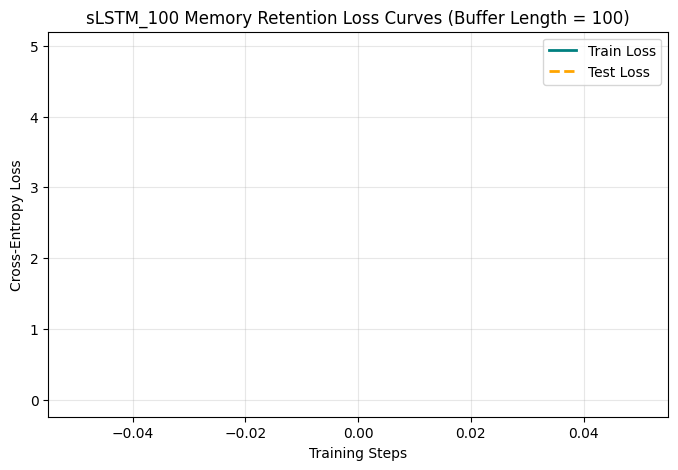

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9499


  0%|          | 0/10 [00:00<?, ?it/s]

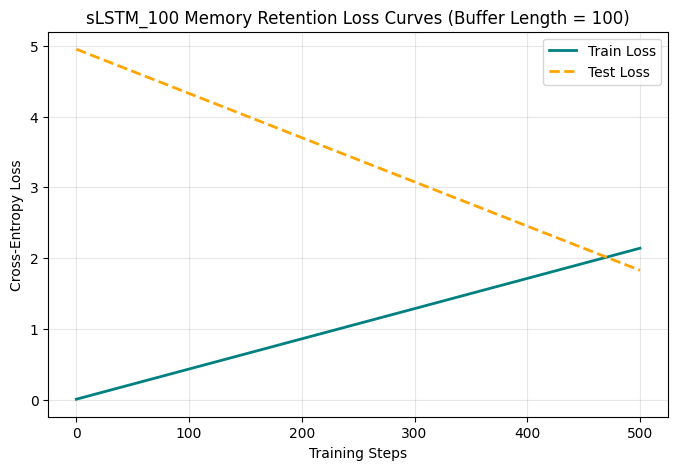

STEP: 500 | TRAIN LOSS: 2.1412 | TEST LOSS: 1.8291


  0%|          | 0/10 [00:00<?, ?it/s]

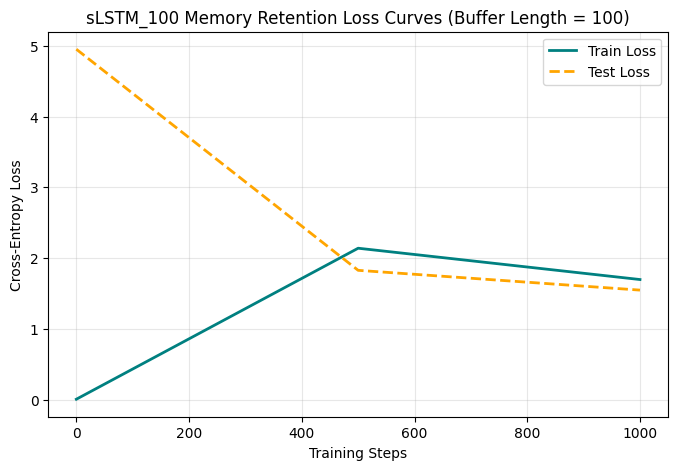

STEP: 1000 | TRAIN LOSS: 1.6992 | TEST LOSS: 1.5499


  0%|          | 0/10 [00:00<?, ?it/s]

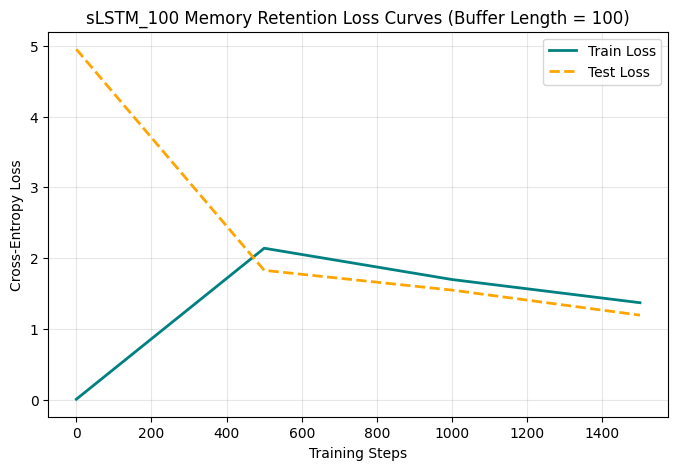

STEP: 1500 | TRAIN LOSS: 1.3721 | TEST LOSS: 1.1964


  0%|          | 0/10 [00:00<?, ?it/s]

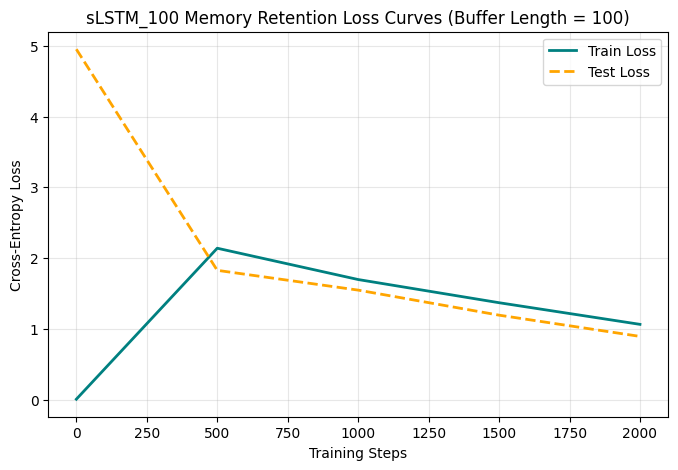

STEP: 2000 | TRAIN LOSS: 1.0666 | TEST LOSS: 0.8966


  0%|          | 0/10 [00:00<?, ?it/s]

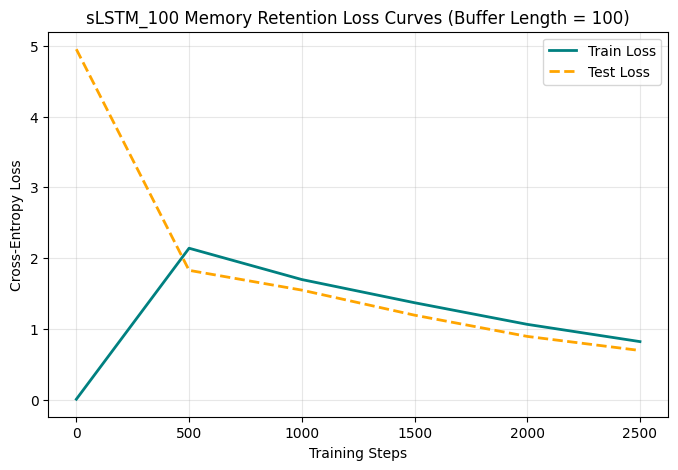

STEP: 2500 | TRAIN LOSS: 0.8230 | TEST LOSS: 0.6977


  0%|          | 0/10 [00:00<?, ?it/s]

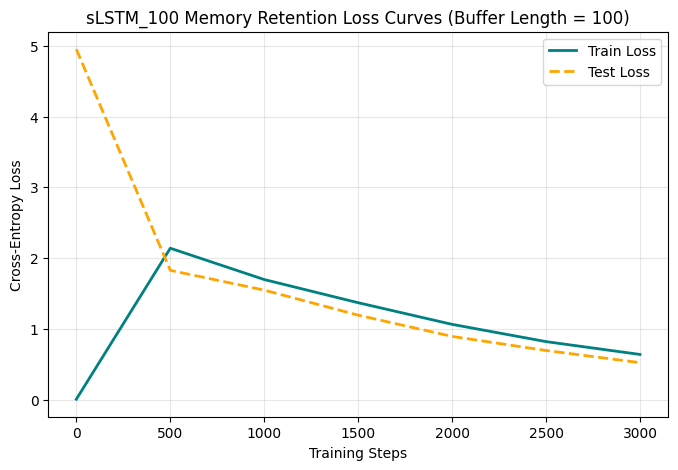

STEP: 3000 | TRAIN LOSS: 0.6419 | TEST LOSS: 0.5260


  0%|          | 0/10 [00:00<?, ?it/s]

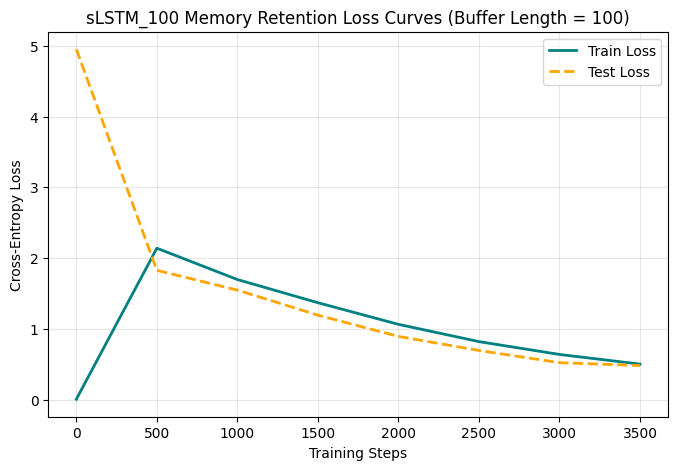

STEP: 3500 | TRAIN LOSS: 0.5056 | TEST LOSS: 0.4853


  0%|          | 0/10 [00:00<?, ?it/s]

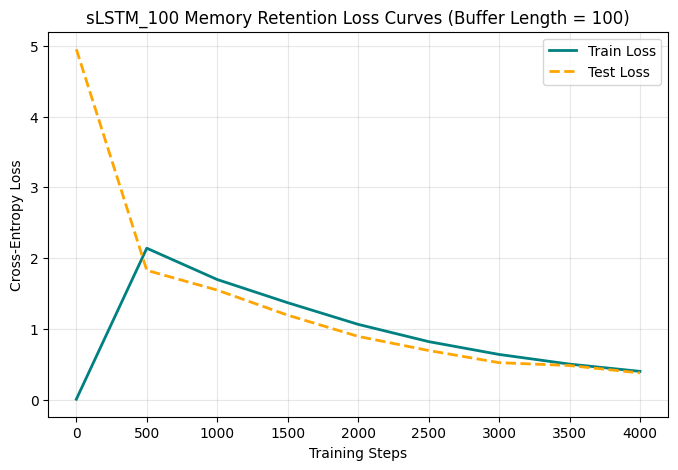

STEP: 4000 | TRAIN LOSS: 0.4030 | TEST LOSS: 0.3808


  0%|          | 0/10 [00:00<?, ?it/s]

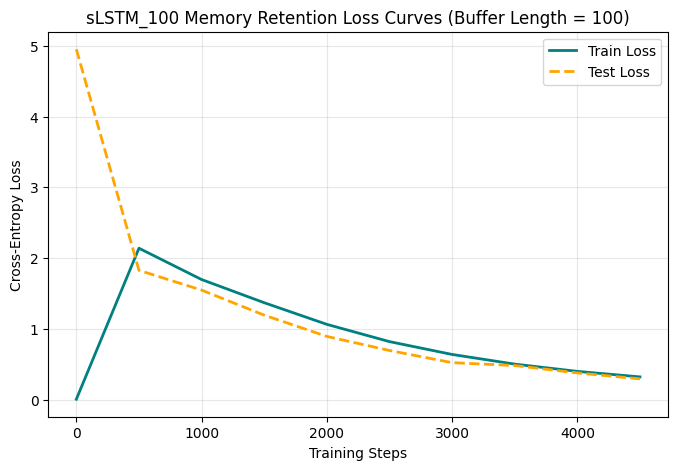

STEP: 4500 | TRAIN LOSS: 0.3252 | TEST LOSS: 0.2971


  0%|          | 0/10 [00:00<?, ?it/s]

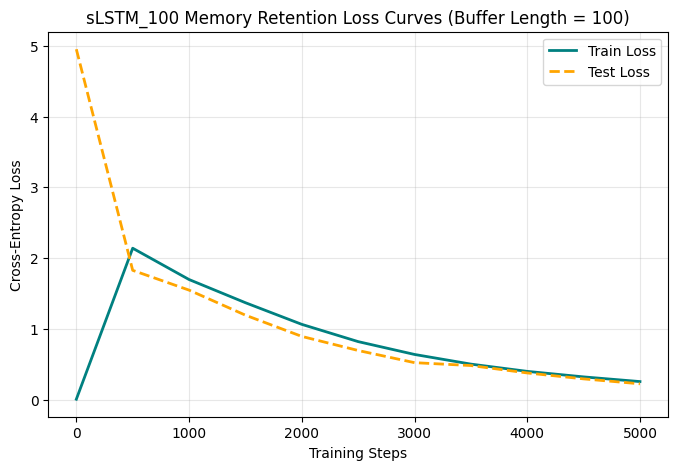

STEP: 5000 | TRAIN LOSS: 0.2590 | TEST LOSS: 0.2275


  0%|          | 0/10 [00:00<?, ?it/s]

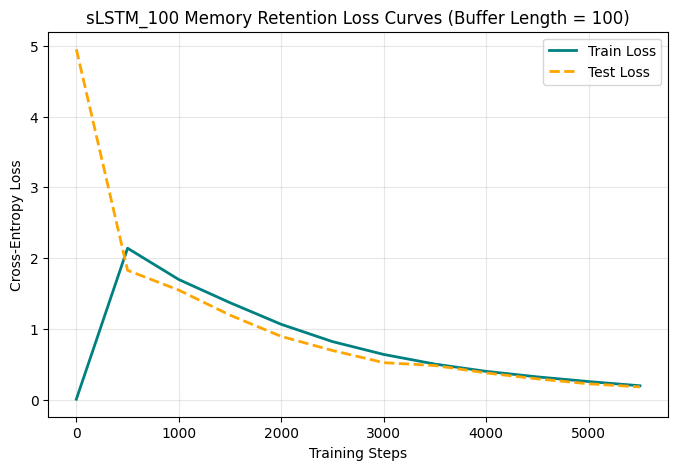

STEP: 5500 | TRAIN LOSS: 0.1998 | TEST LOSS: 0.1835


  0%|          | 0/10 [00:00<?, ?it/s]

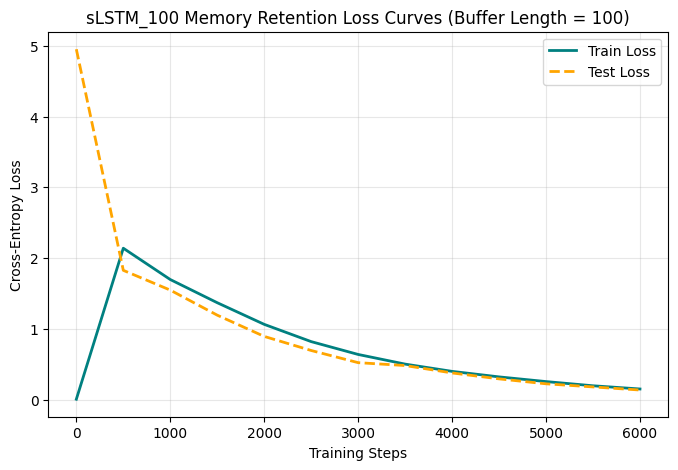

STEP: 6000 | TRAIN LOSS: 0.1545 | TEST LOSS: 0.1398


  0%|          | 0/10 [00:00<?, ?it/s]

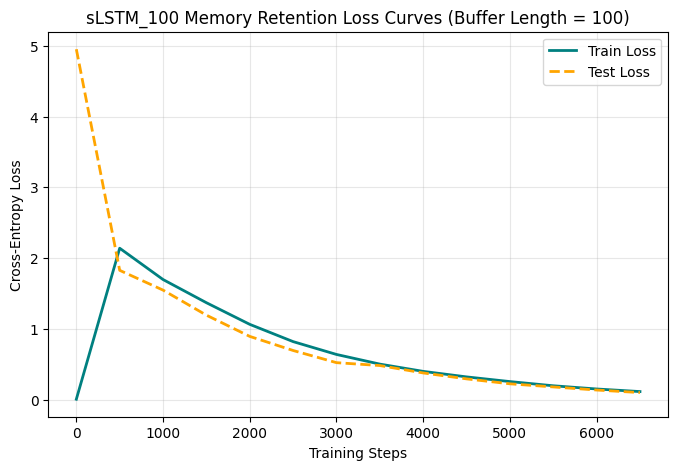

STEP: 6500 | TRAIN LOSS: 0.1180 | TEST LOSS: 0.1037


  0%|          | 0/10 [00:00<?, ?it/s]

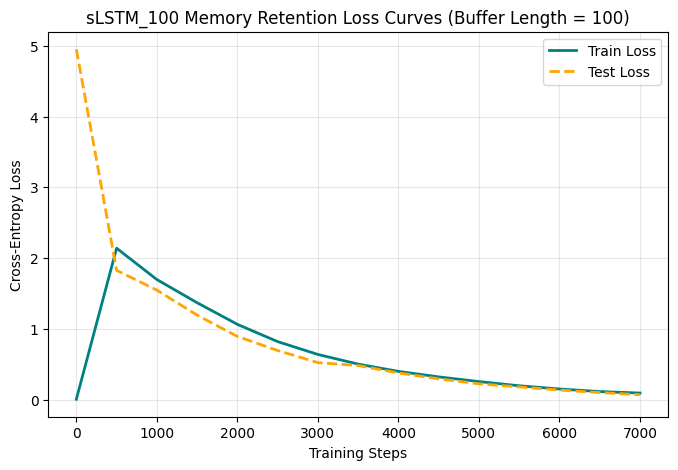

STEP: 7000 | TRAIN LOSS: 0.0971 | TEST LOSS: 0.0737


In [5]:
run_training_ex1(sLSTM_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_sLSTM, 
                 test_break=500, 
                 model_name="sLSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

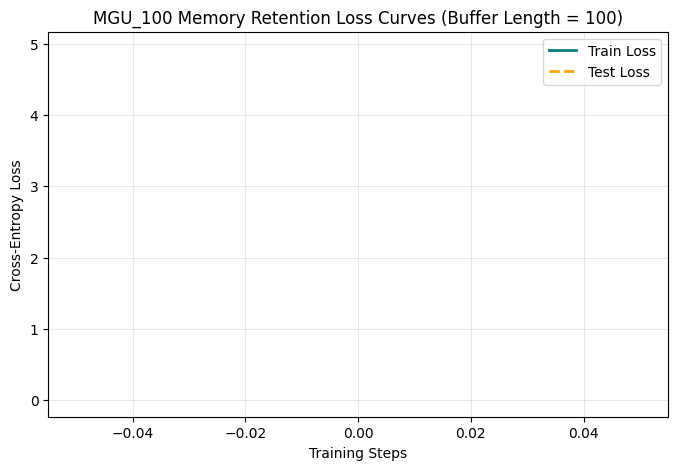

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9260


  0%|          | 0/10 [00:00<?, ?it/s]

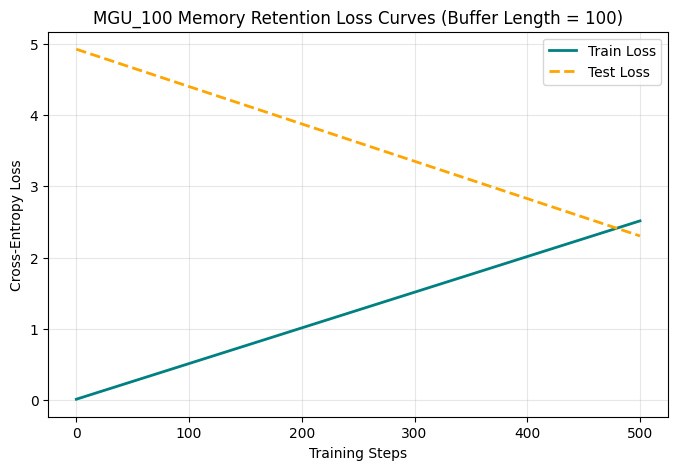

STEP: 500 | TRAIN LOSS: 2.5150 | TEST LOSS: 2.3034


  0%|          | 0/10 [00:00<?, ?it/s]

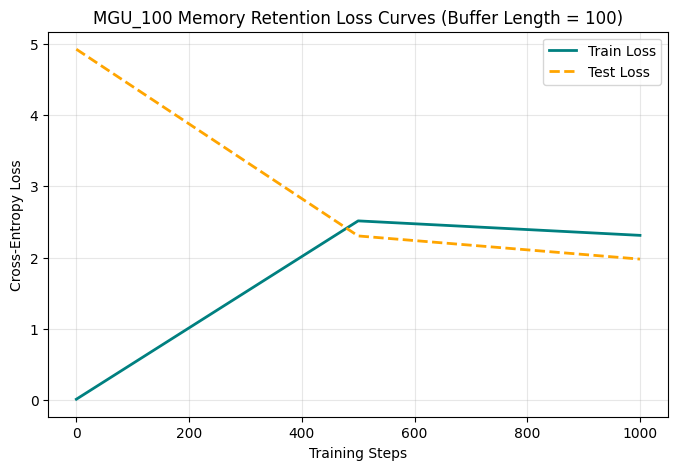

STEP: 1000 | TRAIN LOSS: 2.3117 | TEST LOSS: 1.9779


  0%|          | 0/10 [00:00<?, ?it/s]

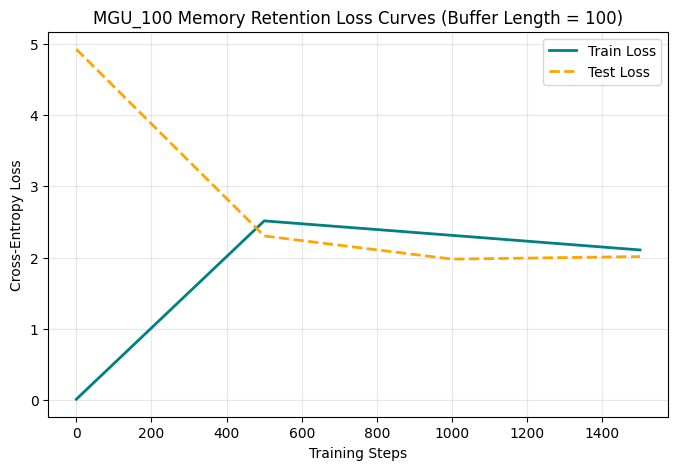

STEP: 1500 | TRAIN LOSS: 2.1067 | TEST LOSS: 2.0142


  0%|          | 0/10 [00:00<?, ?it/s]

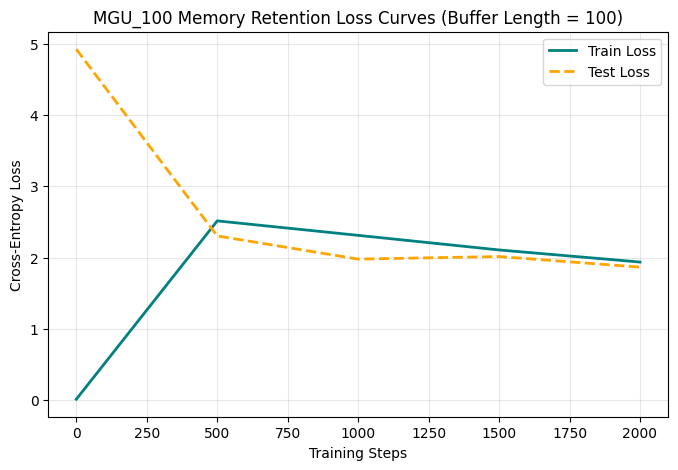

STEP: 2000 | TRAIN LOSS: 1.9368 | TEST LOSS: 1.8655


  0%|          | 0/10 [00:00<?, ?it/s]

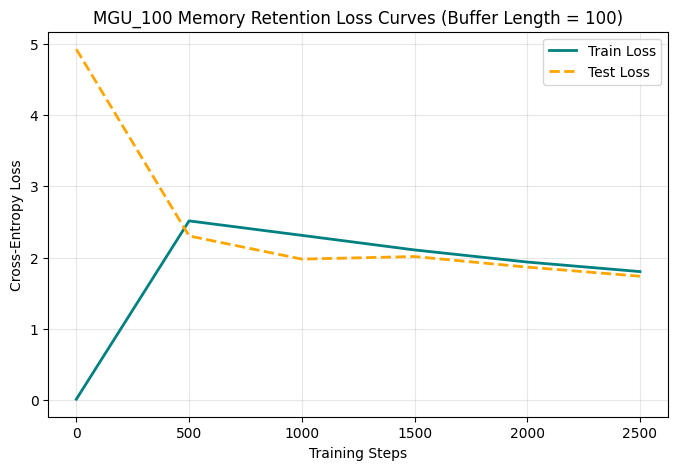

STEP: 2500 | TRAIN LOSS: 1.8025 | TEST LOSS: 1.7377


  0%|          | 0/10 [00:00<?, ?it/s]

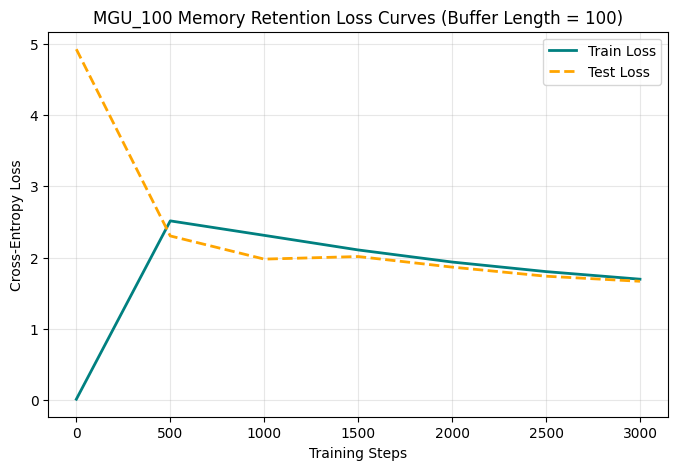

STEP: 3000 | TRAIN LOSS: 1.6959 | TEST LOSS: 1.6665


  0%|          | 0/10 [00:00<?, ?it/s]

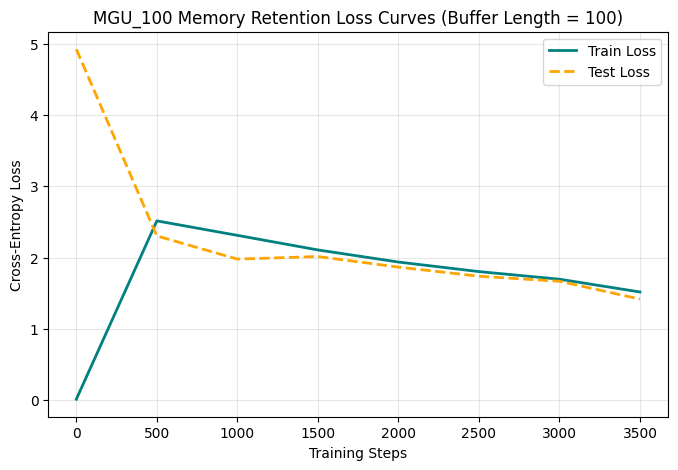

STEP: 3500 | TRAIN LOSS: 1.5162 | TEST LOSS: 1.4165


  0%|          | 0/10 [00:00<?, ?it/s]

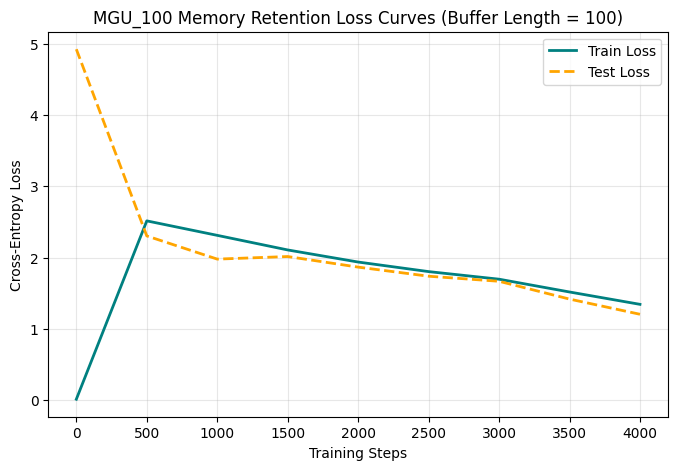

STEP: 4000 | TRAIN LOSS: 1.3427 | TEST LOSS: 1.2032


  0%|          | 0/10 [00:00<?, ?it/s]

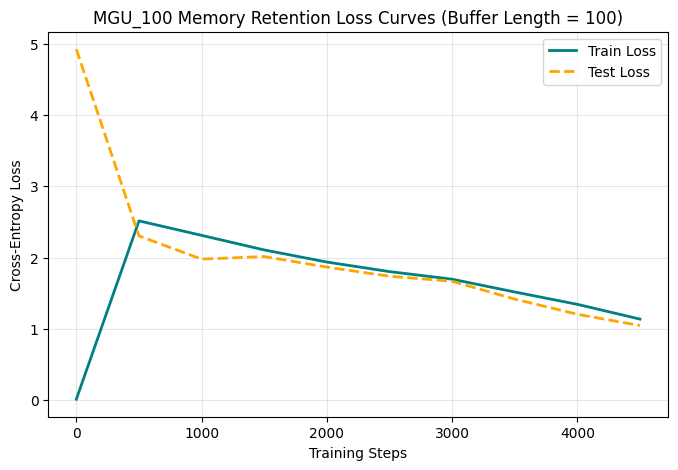

STEP: 4500 | TRAIN LOSS: 1.1354 | TEST LOSS: 1.0448


  0%|          | 0/10 [00:00<?, ?it/s]

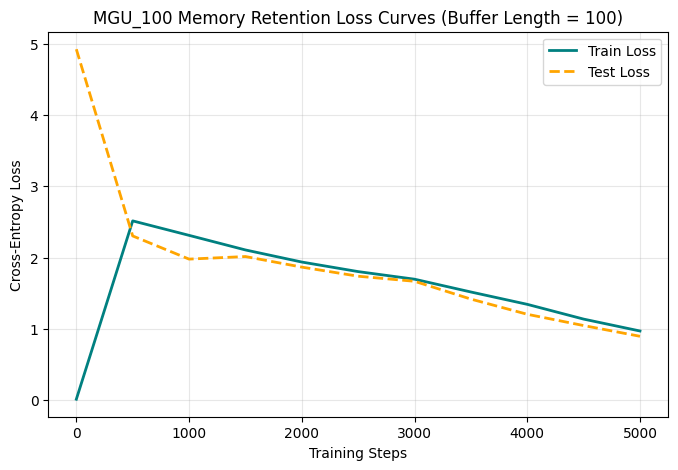

STEP: 5000 | TRAIN LOSS: 0.9682 | TEST LOSS: 0.8939


  0%|          | 0/10 [00:00<?, ?it/s]

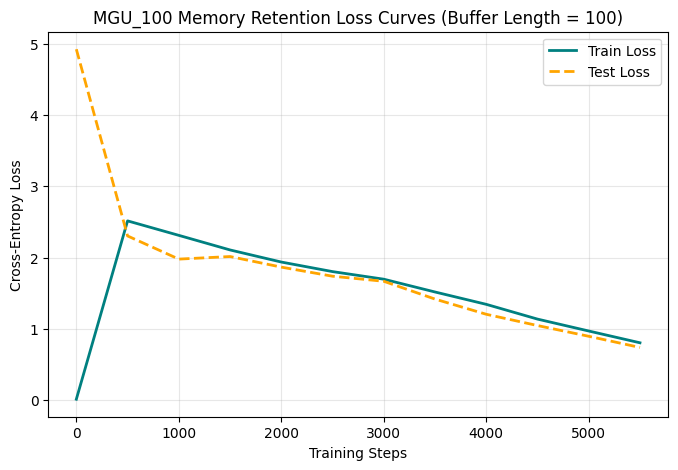

STEP: 5500 | TRAIN LOSS: 0.8026 | TEST LOSS: 0.7370


  0%|          | 0/10 [00:00<?, ?it/s]

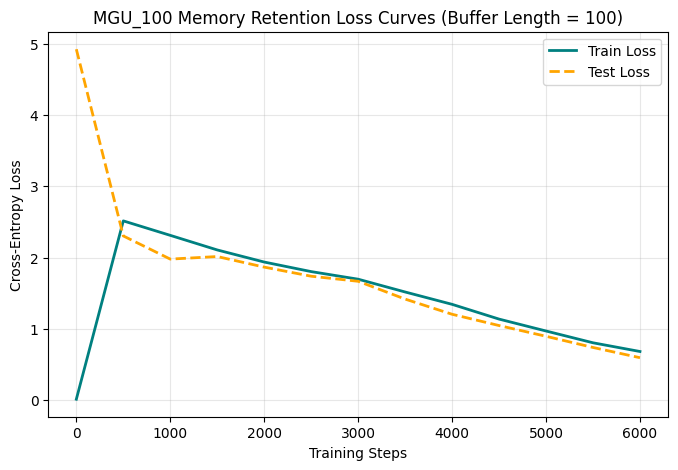

STEP: 6000 | TRAIN LOSS: 0.6802 | TEST LOSS: 0.5930


  0%|          | 0/10 [00:00<?, ?it/s]

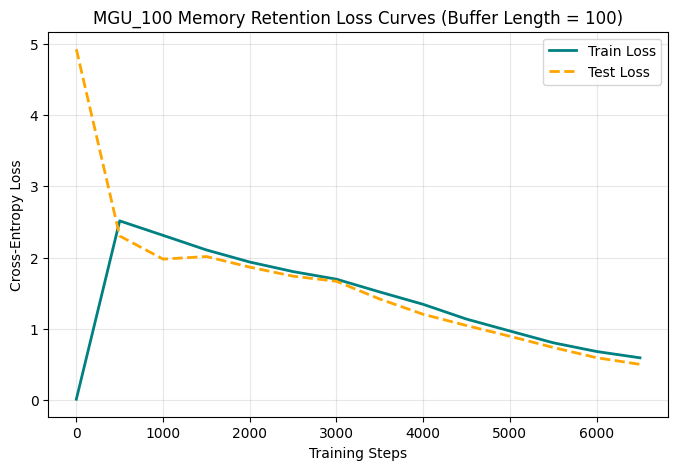

STEP: 6500 | TRAIN LOSS: 0.5917 | TEST LOSS: 0.4996


  0%|          | 0/10 [00:00<?, ?it/s]

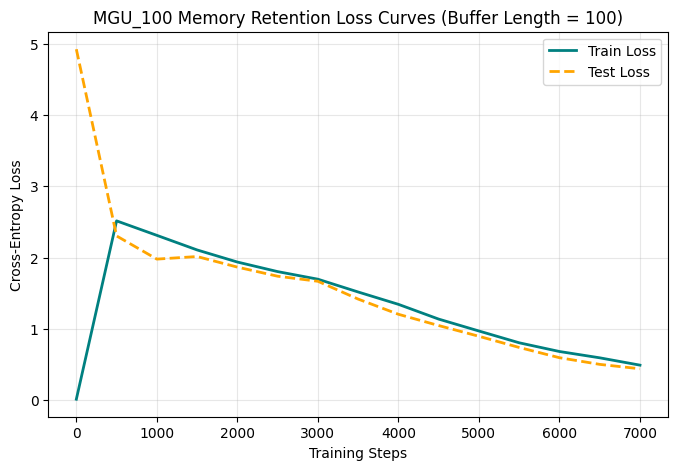

STEP: 7000 | TRAIN LOSS: 0.4886 | TEST LOSS: 0.4376


In [6]:
steps_history = []
train_history = []
test_history = []

run_training_ex1(MGU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_MGU, 
                 test_break=500, 
                 model_name="MGU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

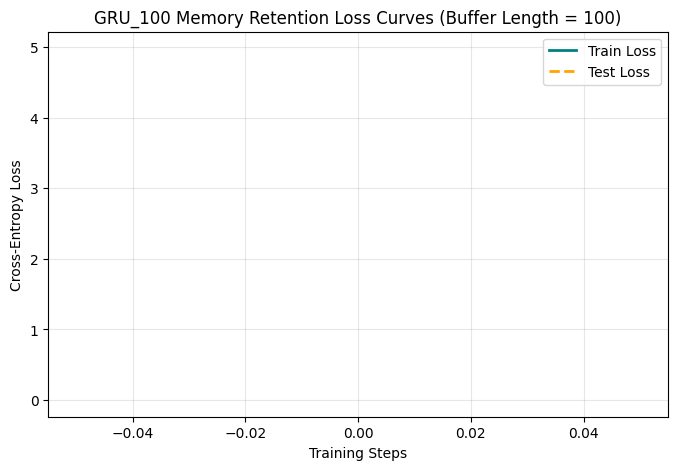

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9734


  0%|          | 0/10 [00:00<?, ?it/s]

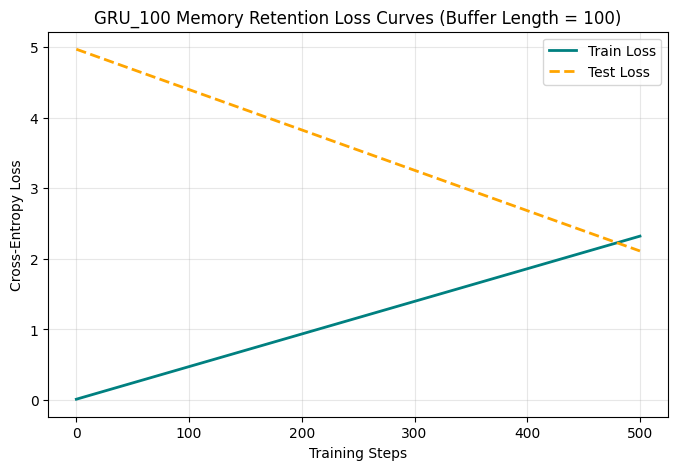

STEP: 500 | TRAIN LOSS: 2.3228 | TEST LOSS: 2.1120


  0%|          | 0/10 [00:00<?, ?it/s]

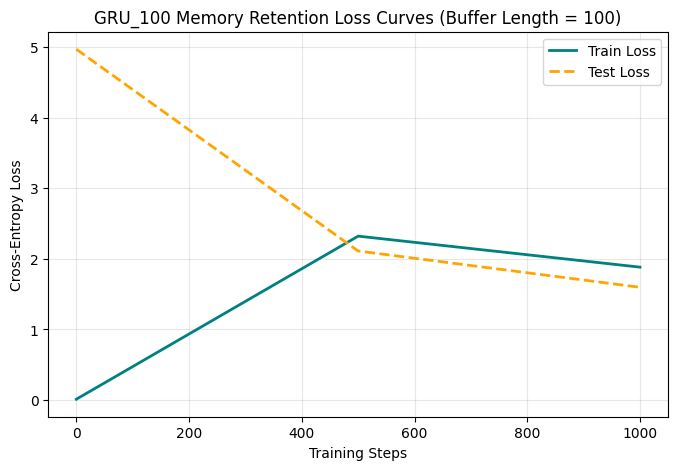

STEP: 1000 | TRAIN LOSS: 1.8829 | TEST LOSS: 1.5973


  0%|          | 0/10 [00:00<?, ?it/s]

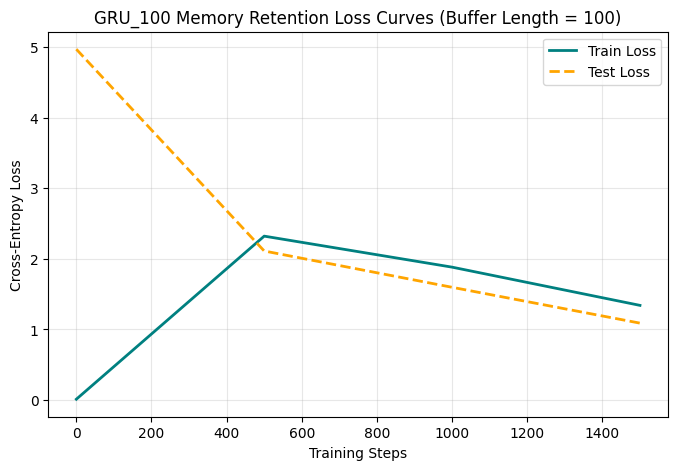

STEP: 1500 | TRAIN LOSS: 1.3409 | TEST LOSS: 1.0890


  0%|          | 0/10 [00:00<?, ?it/s]

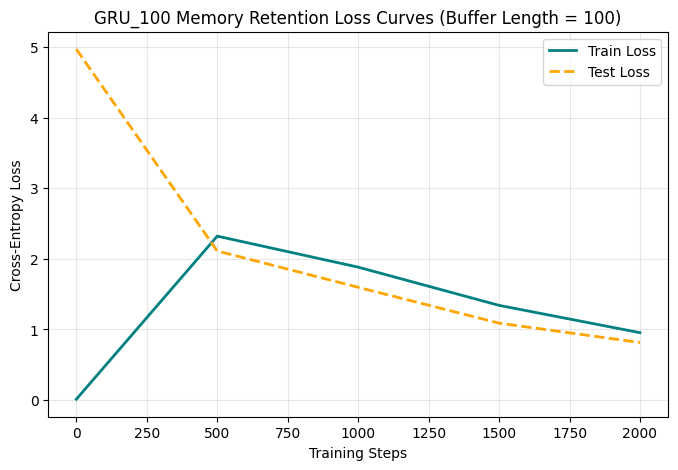

STEP: 2000 | TRAIN LOSS: 0.9537 | TEST LOSS: 0.8141


  0%|          | 0/10 [00:00<?, ?it/s]

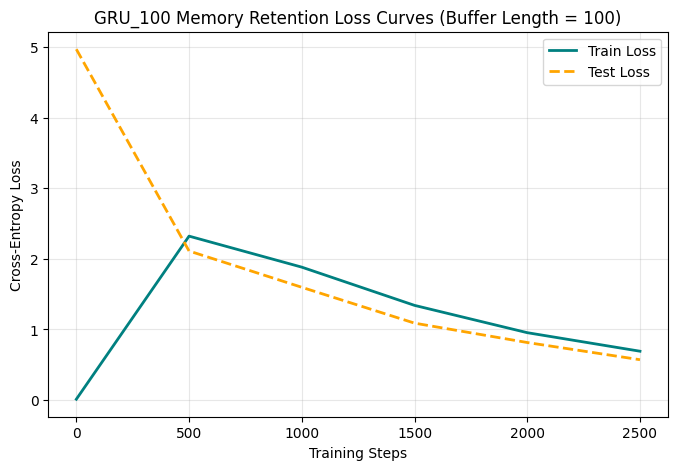

STEP: 2500 | TRAIN LOSS: 0.6907 | TEST LOSS: 0.5703


  0%|          | 0/10 [00:00<?, ?it/s]

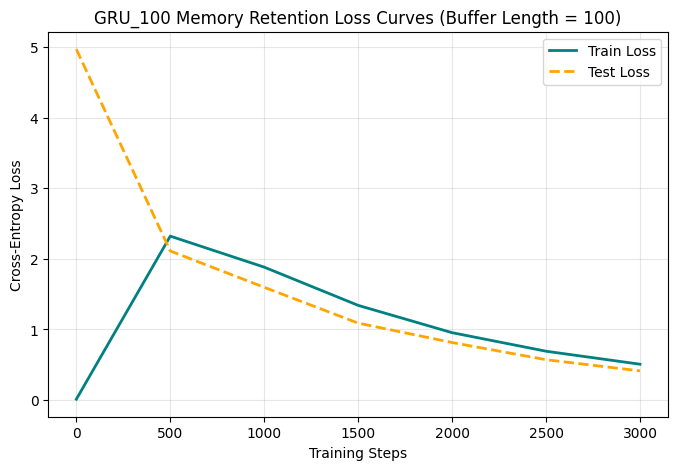

STEP: 3000 | TRAIN LOSS: 0.5066 | TEST LOSS: 0.4121


  0%|          | 0/10 [00:00<?, ?it/s]

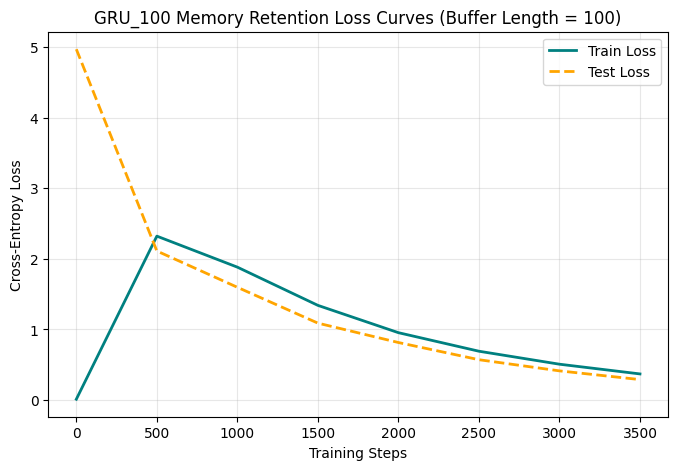

STEP: 3500 | TRAIN LOSS: 0.3687 | TEST LOSS: 0.2885


  0%|          | 0/10 [00:00<?, ?it/s]

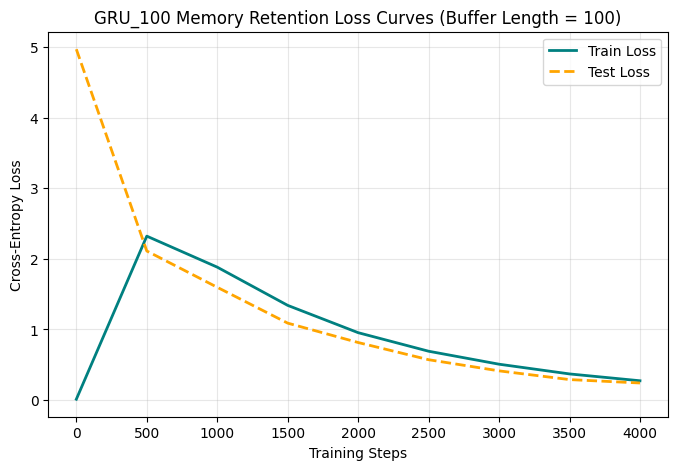

STEP: 4000 | TRAIN LOSS: 0.2718 | TEST LOSS: 0.2401


  0%|          | 0/10 [00:00<?, ?it/s]

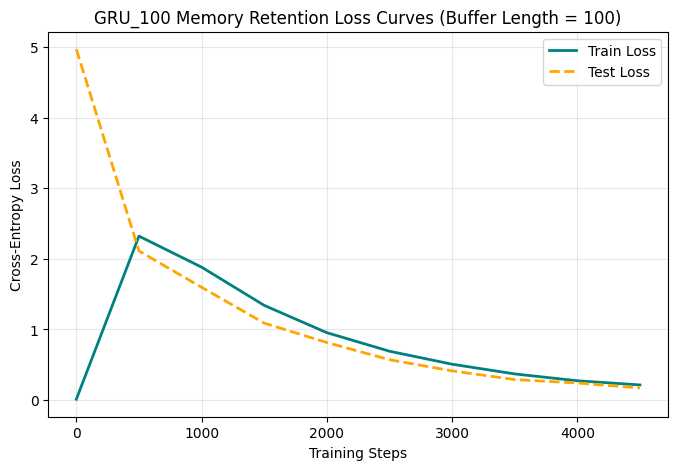

STEP: 4500 | TRAIN LOSS: 0.2126 | TEST LOSS: 0.1701


  0%|          | 0/10 [00:00<?, ?it/s]

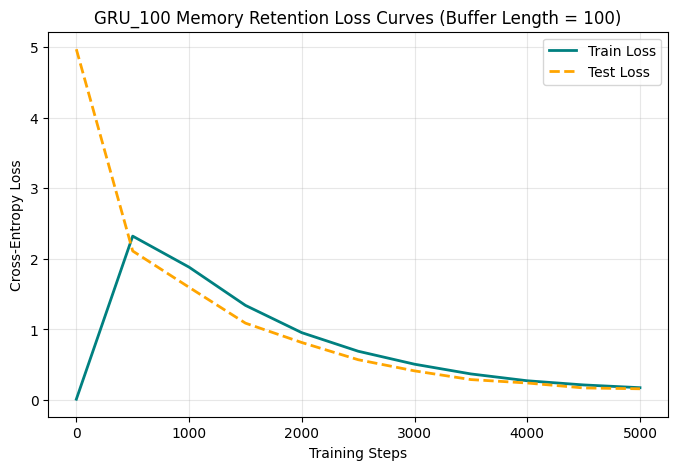

STEP: 5000 | TRAIN LOSS: 0.1736 | TEST LOSS: 0.1581


  0%|          | 0/10 [00:00<?, ?it/s]

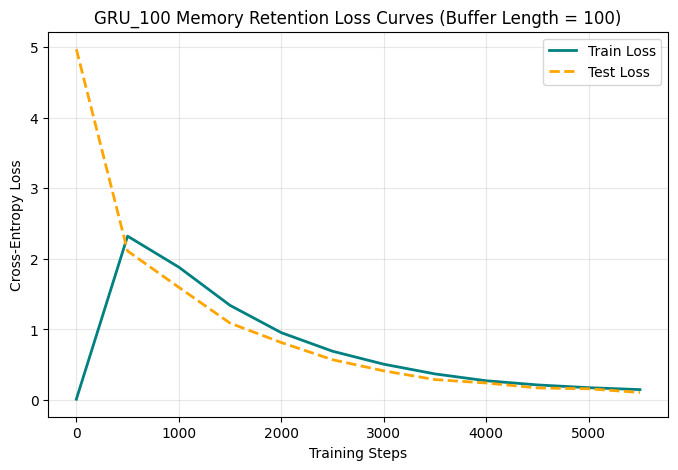

STEP: 5500 | TRAIN LOSS: 0.1462 | TEST LOSS: 0.1055


  0%|          | 0/10 [00:00<?, ?it/s]

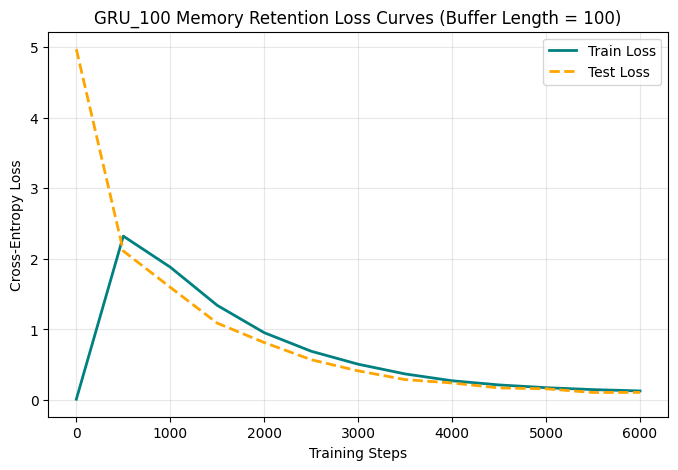

STEP: 6000 | TRAIN LOSS: 0.1273 | TEST LOSS: 0.1067


  0%|          | 0/10 [00:00<?, ?it/s]

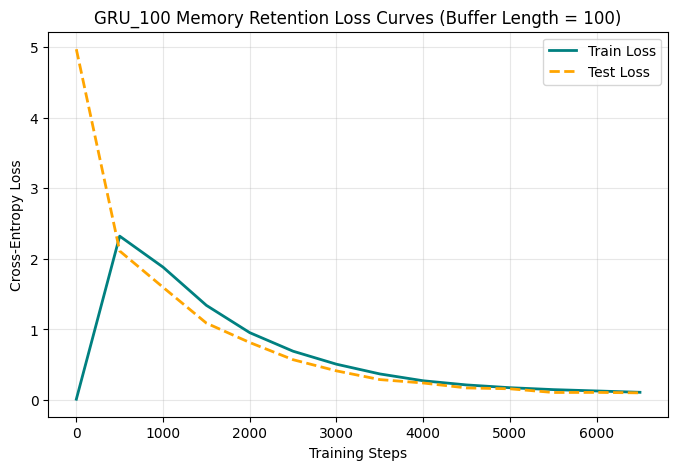

STEP: 6500 | TRAIN LOSS: 0.1082 | TEST LOSS: 0.1003


  0%|          | 0/10 [00:00<?, ?it/s]

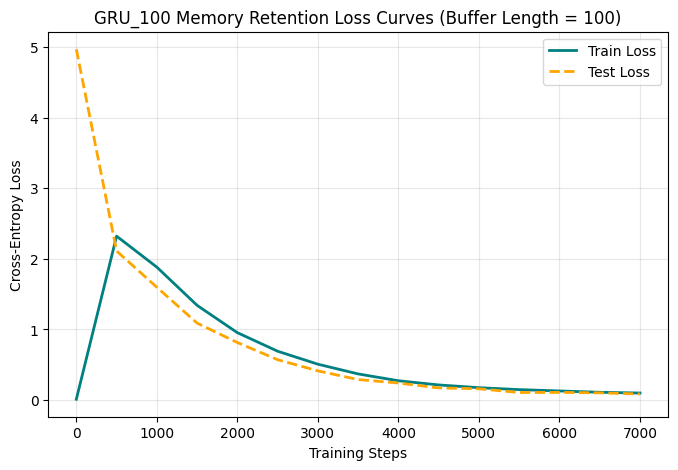

STEP: 7000 | TRAIN LOSS: 0.0977 | TEST LOSS: 0.0849


In [7]:
steps_history = []
train_history = []
test_history = []

run_training_ex1(GRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_GRU, 
                 test_break=500, 
                 model_name="GRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

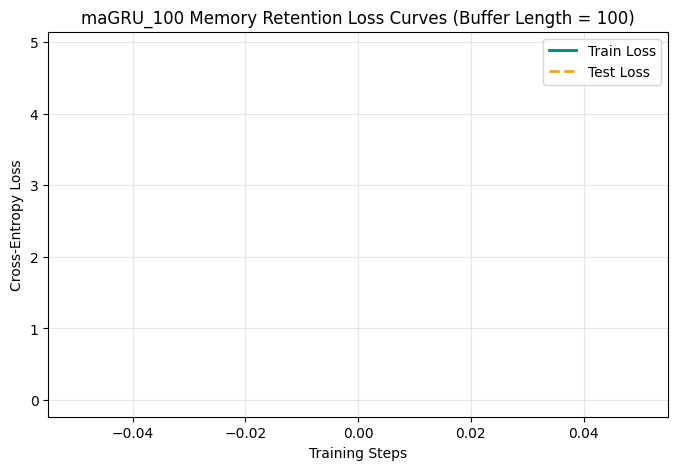

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9040


  0%|          | 0/10 [00:00<?, ?it/s]

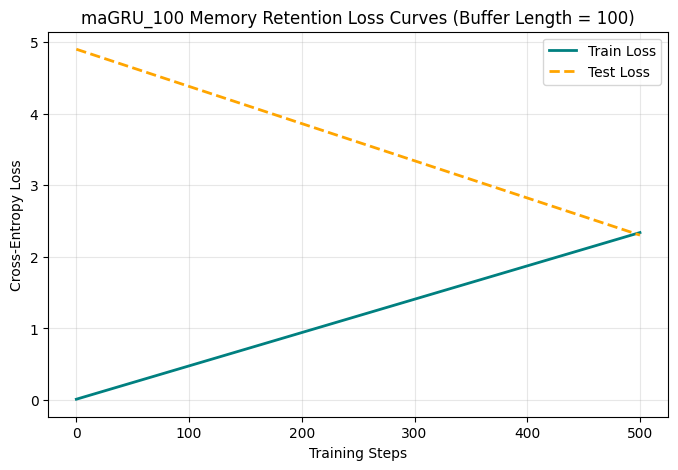

STEP: 500 | TRAIN LOSS: 2.3404 | TEST LOSS: 2.3044


  0%|          | 0/10 [00:00<?, ?it/s]

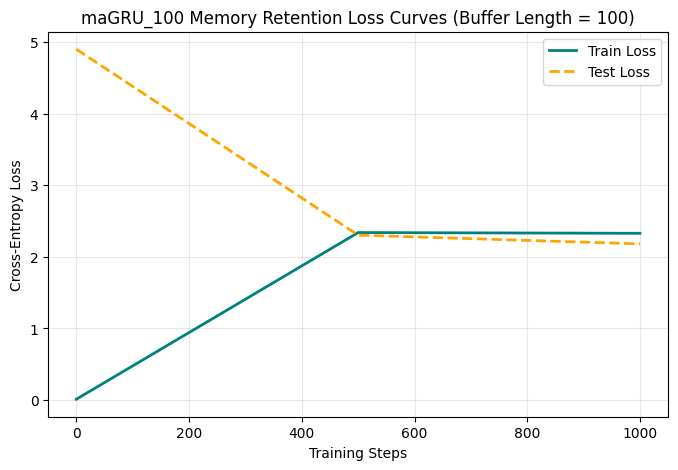

STEP: 1000 | TRAIN LOSS: 2.3300 | TEST LOSS: 2.1818


  0%|          | 0/10 [00:00<?, ?it/s]

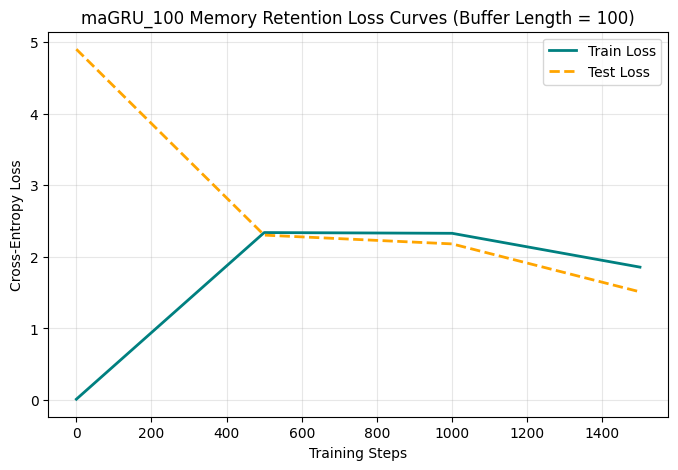

STEP: 1500 | TRAIN LOSS: 1.8570 | TEST LOSS: 1.5114


  0%|          | 0/10 [00:00<?, ?it/s]

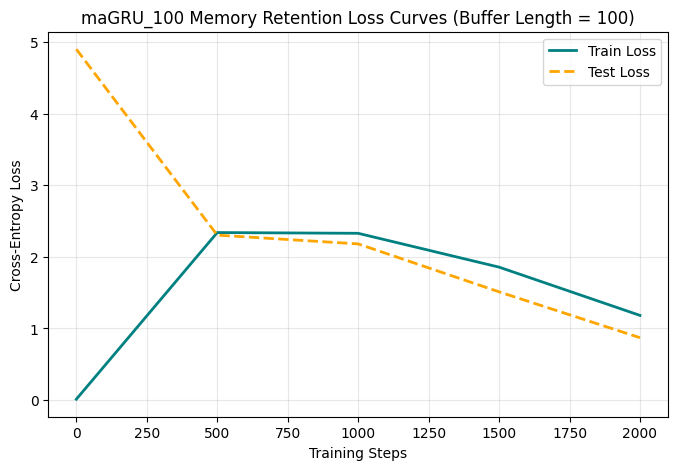

STEP: 2000 | TRAIN LOSS: 1.1820 | TEST LOSS: 0.8704


  0%|          | 0/10 [00:00<?, ?it/s]

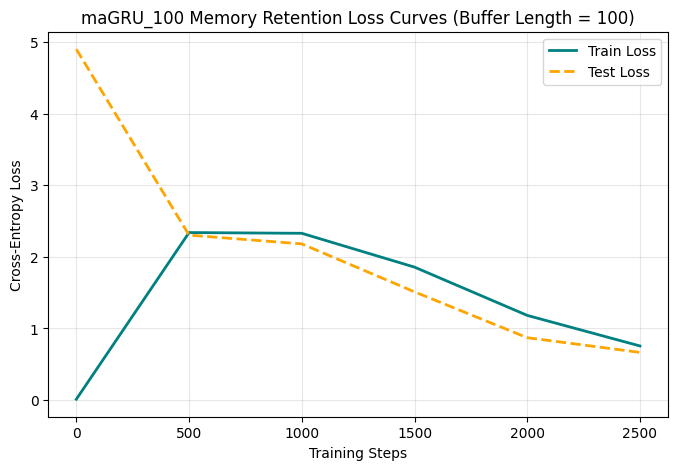

STEP: 2500 | TRAIN LOSS: 0.7547 | TEST LOSS: 0.6646


  0%|          | 0/10 [00:00<?, ?it/s]

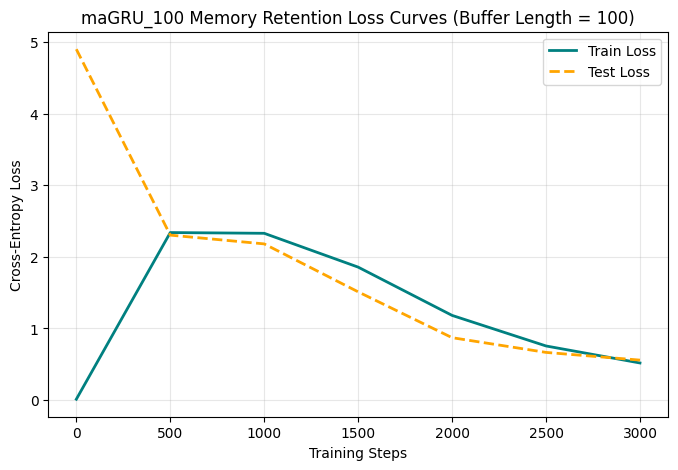

STEP: 3000 | TRAIN LOSS: 0.5168 | TEST LOSS: 0.5568


  0%|          | 0/10 [00:00<?, ?it/s]

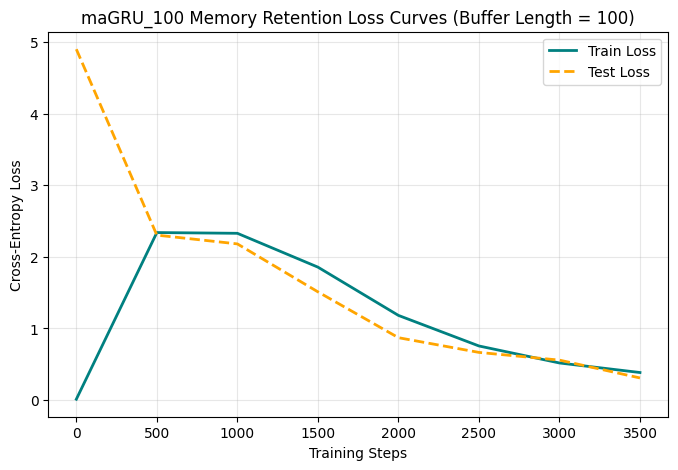

STEP: 3500 | TRAIN LOSS: 0.3834 | TEST LOSS: 0.3073


  0%|          | 0/10 [00:00<?, ?it/s]

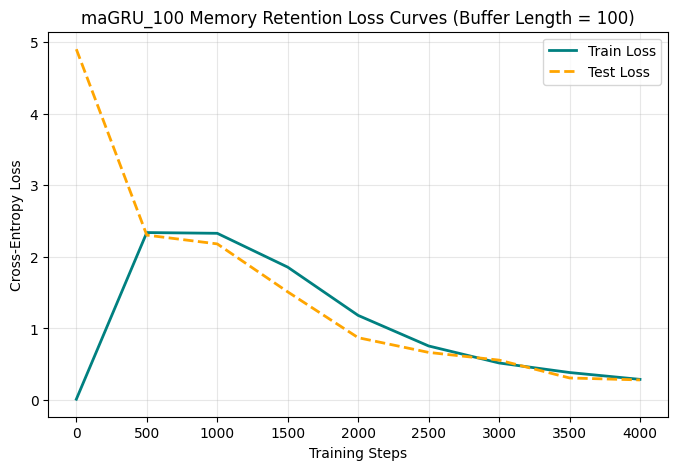

STEP: 4000 | TRAIN LOSS: 0.2875 | TEST LOSS: 0.2798


  0%|          | 0/10 [00:00<?, ?it/s]

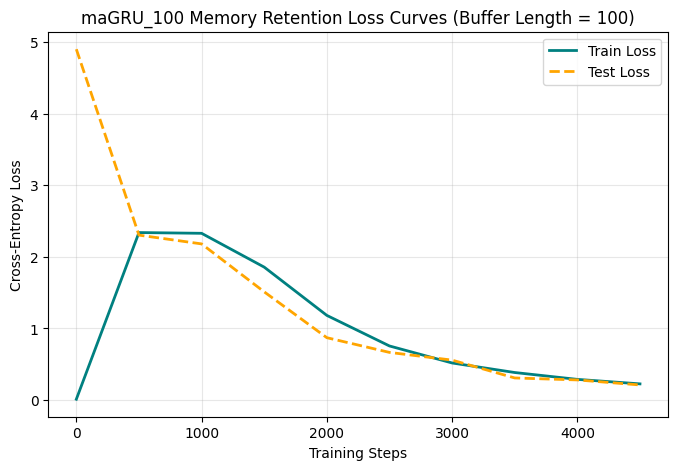

STEP: 4500 | TRAIN LOSS: 0.2246 | TEST LOSS: 0.2094


  0%|          | 0/10 [00:00<?, ?it/s]

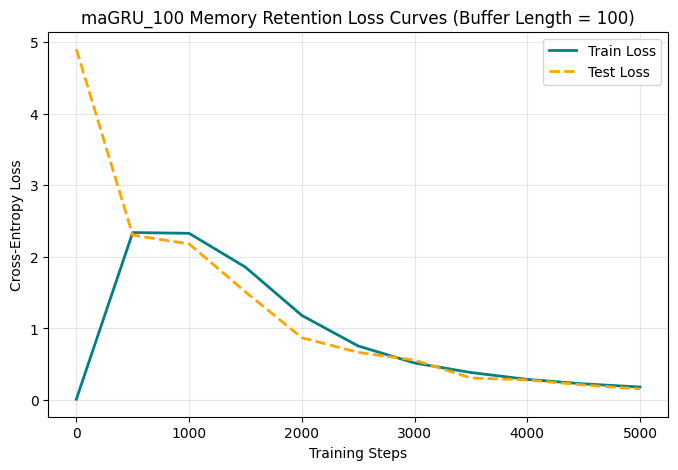

STEP: 5000 | TRAIN LOSS: 0.1805 | TEST LOSS: 0.1531


  0%|          | 0/10 [00:00<?, ?it/s]

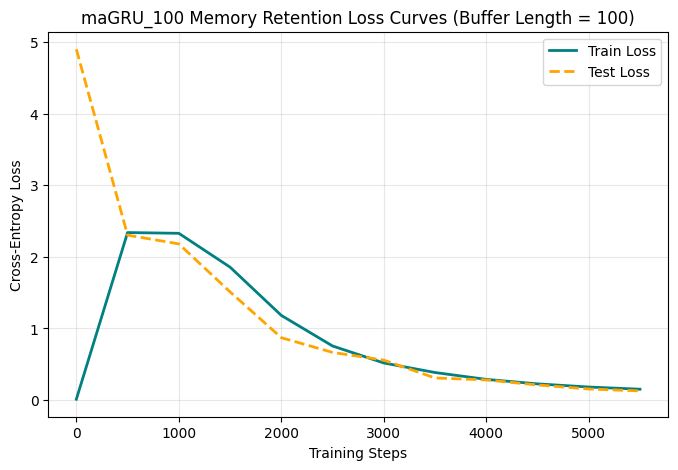

STEP: 5500 | TRAIN LOSS: 0.1501 | TEST LOSS: 0.1258


  0%|          | 0/10 [00:00<?, ?it/s]

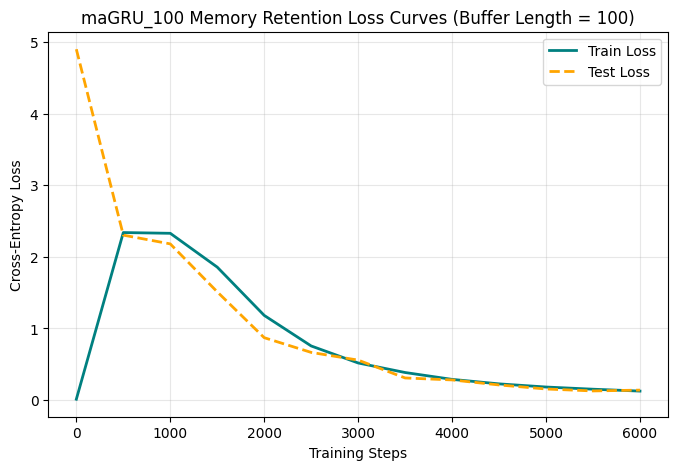

STEP: 6000 | TRAIN LOSS: 0.1236 | TEST LOSS: 0.1373


  0%|          | 0/10 [00:00<?, ?it/s]

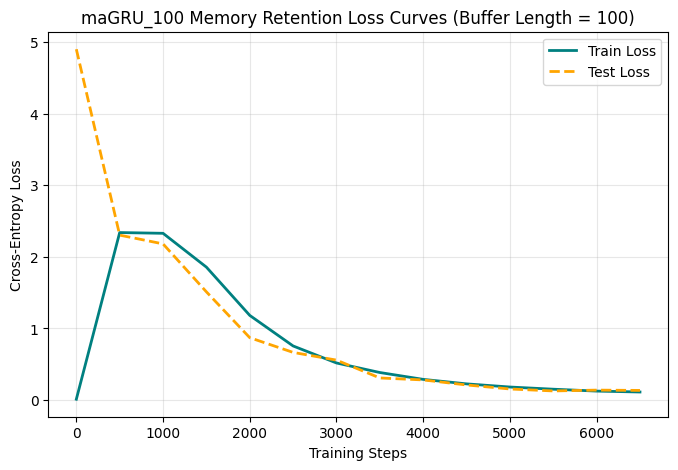

STEP: 6500 | TRAIN LOSS: 0.1109 | TEST LOSS: 0.1330


  0%|          | 0/10 [00:00<?, ?it/s]

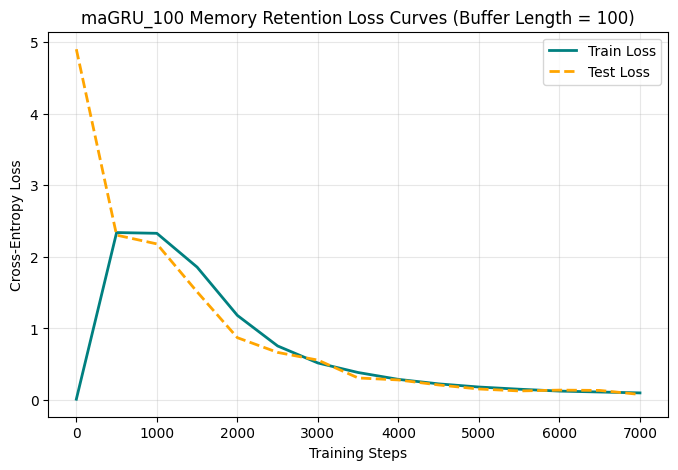

STEP: 7000 | TRAIN LOSS: 0.0984 | TEST LOSS: 0.0770


In [8]:
steps_history = []
train_history = []
test_history = []

run_training_ex1(maGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_maGRU, 
                 test_break=500, 
                 model_name="maGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

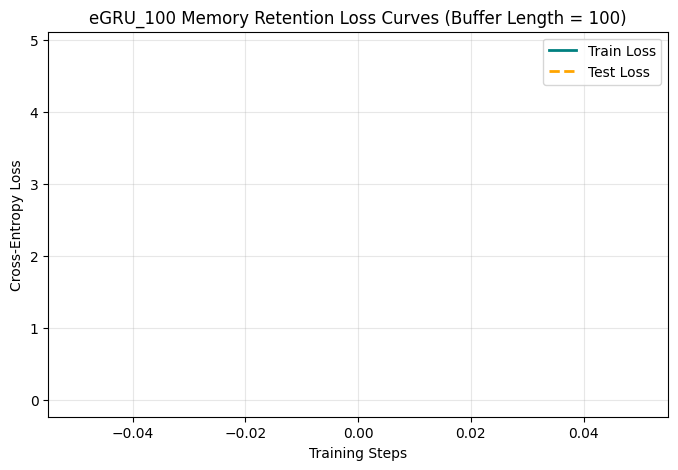

STEP: 0 | TRAIN LOSS: 0.0099 | TEST LOSS: 4.8759


  0%|          | 0/10 [00:00<?, ?it/s]

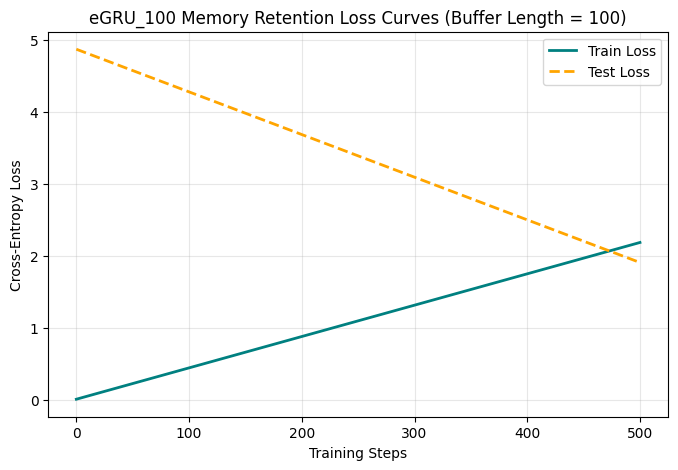

STEP: 500 | TRAIN LOSS: 2.1892 | TEST LOSS: 1.9106


  0%|          | 0/10 [00:00<?, ?it/s]

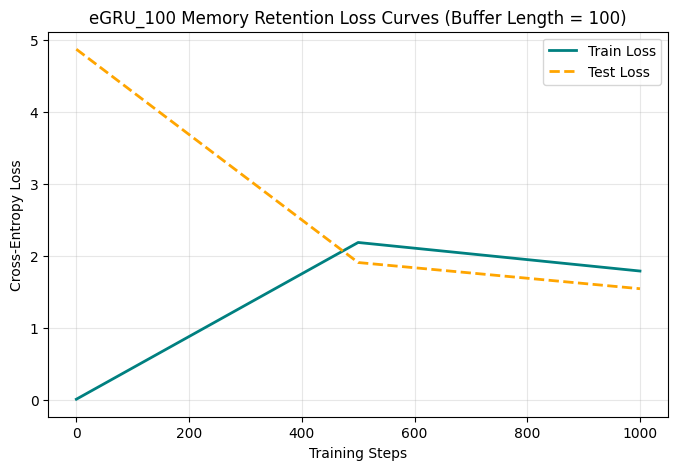

STEP: 1000 | TRAIN LOSS: 1.7920 | TEST LOSS: 1.5463


  0%|          | 0/10 [00:00<?, ?it/s]

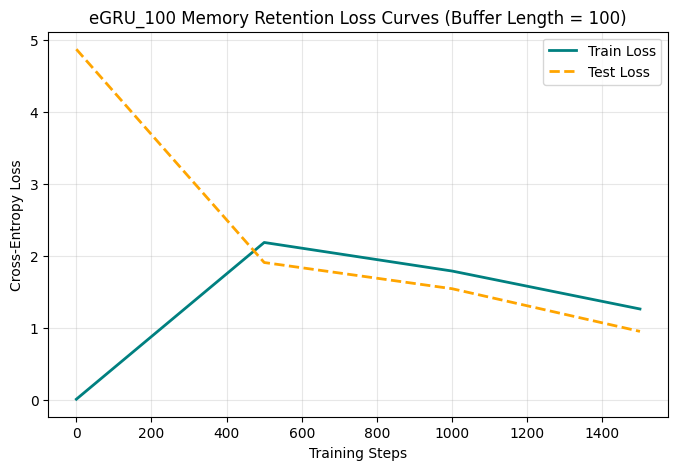

STEP: 1500 | TRAIN LOSS: 1.2645 | TEST LOSS: 0.9530


  0%|          | 0/10 [00:00<?, ?it/s]

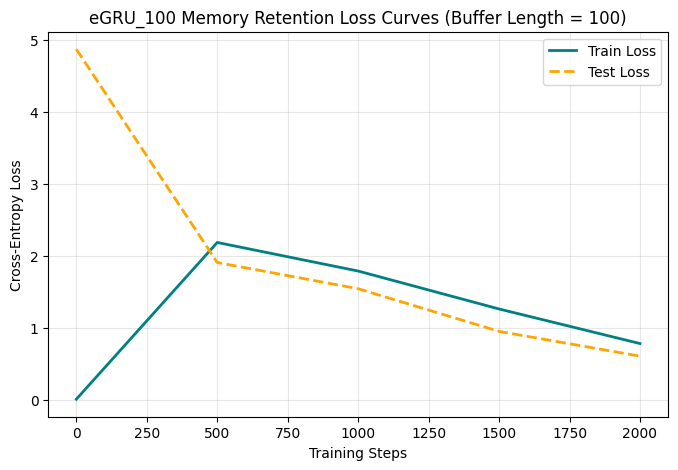

STEP: 2000 | TRAIN LOSS: 0.7840 | TEST LOSS: 0.6088


  0%|          | 0/10 [00:00<?, ?it/s]

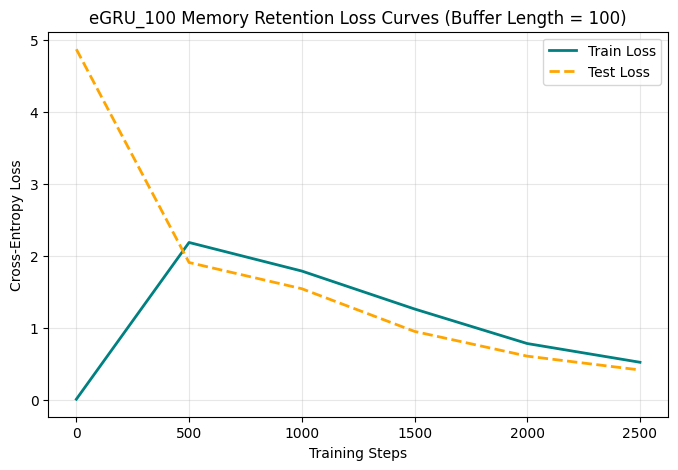

STEP: 2500 | TRAIN LOSS: 0.5236 | TEST LOSS: 0.4166


  0%|          | 0/10 [00:00<?, ?it/s]

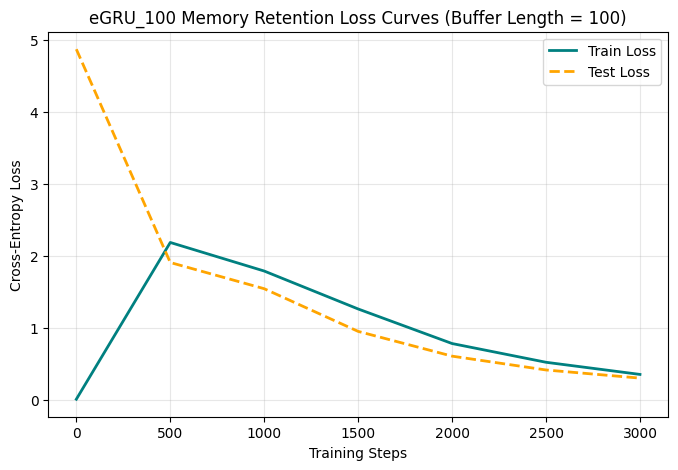

STEP: 3000 | TRAIN LOSS: 0.3547 | TEST LOSS: 0.3033


  0%|          | 0/10 [00:00<?, ?it/s]

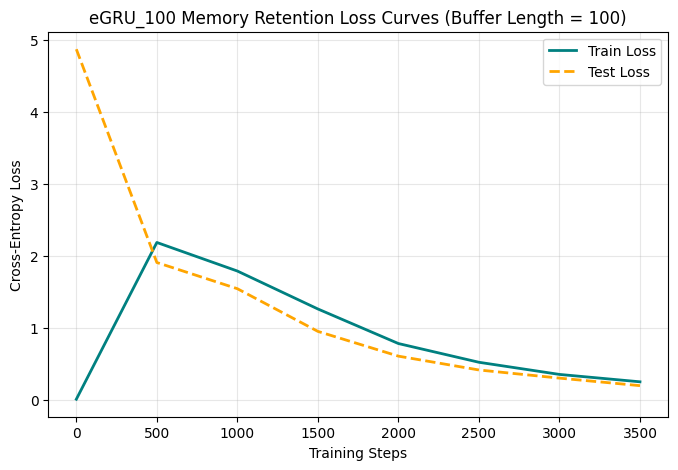

STEP: 3500 | TRAIN LOSS: 0.2520 | TEST LOSS: 0.1986


  0%|          | 0/10 [00:00<?, ?it/s]

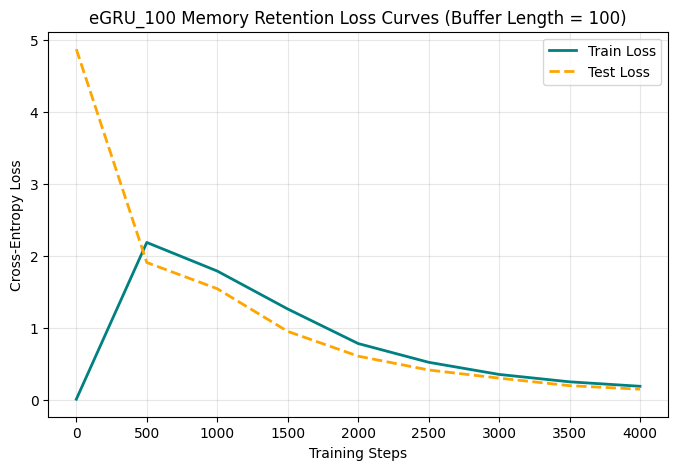

STEP: 4000 | TRAIN LOSS: 0.1899 | TEST LOSS: 0.1492


  0%|          | 0/10 [00:00<?, ?it/s]

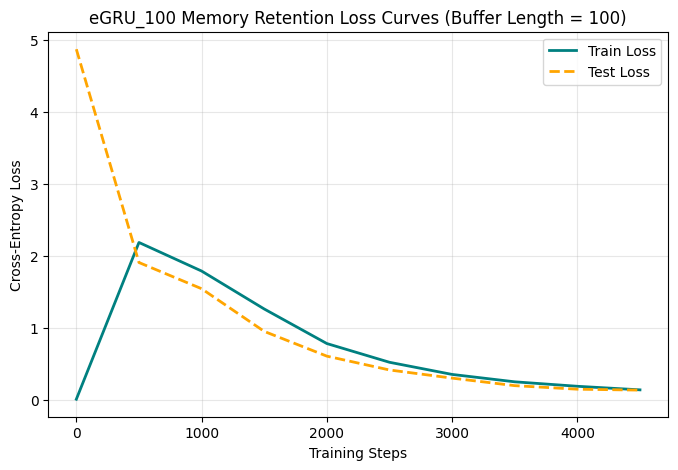

STEP: 4500 | TRAIN LOSS: 0.1402 | TEST LOSS: 0.1364


  0%|          | 0/10 [00:00<?, ?it/s]

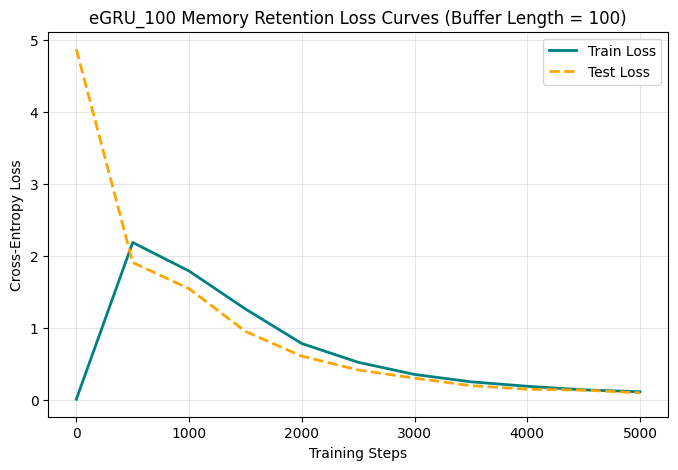

STEP: 5000 | TRAIN LOSS: 0.1143 | TEST LOSS: 0.0989


  0%|          | 0/10 [00:00<?, ?it/s]

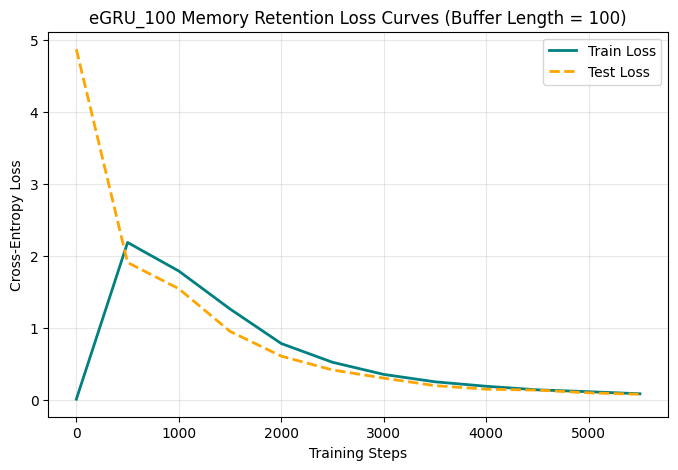

STEP: 5500 | TRAIN LOSS: 0.0857 | TEST LOSS: 0.0788


  0%|          | 0/10 [00:00<?, ?it/s]

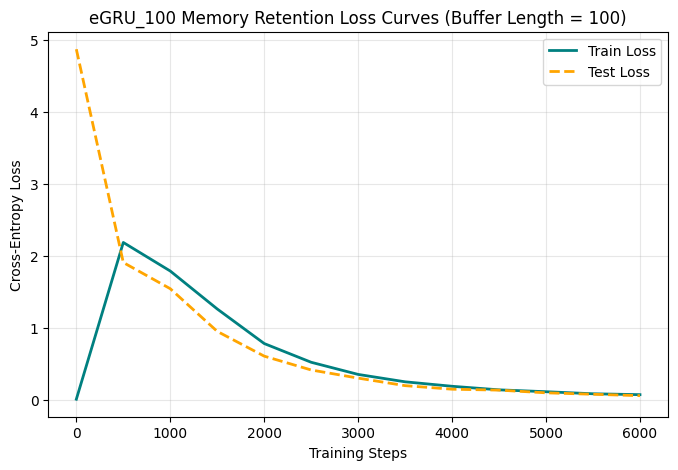

STEP: 6000 | TRAIN LOSS: 0.0733 | TEST LOSS: 0.0593


  0%|          | 0/10 [00:00<?, ?it/s]

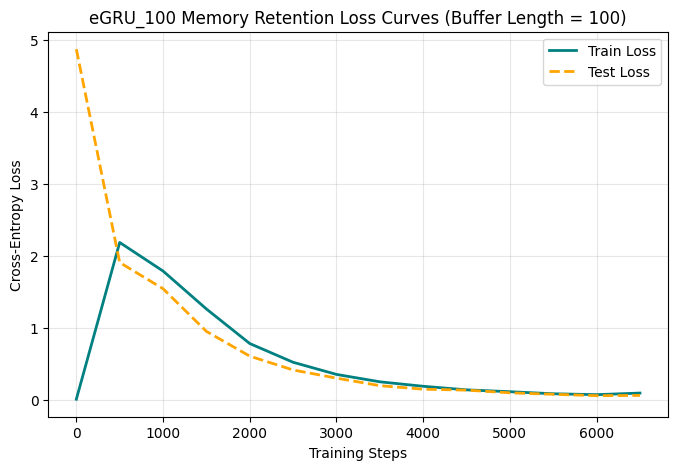

STEP: 6500 | TRAIN LOSS: 0.0954 | TEST LOSS: 0.0627


  0%|          | 0/10 [00:00<?, ?it/s]

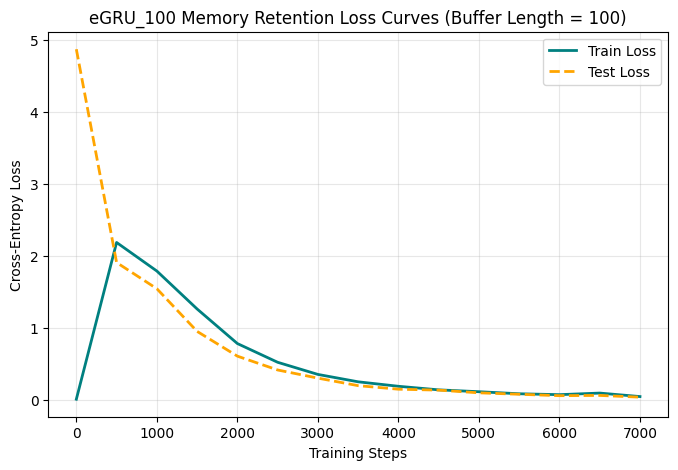

STEP: 7000 | TRAIN LOSS: 0.0469 | TEST LOSS: 0.0386


In [9]:
steps_history = []
train_history = []
test_history = []

run_training_ex1(eGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_eGRU, 
                 test_break=500, 
                 model_name="eGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history)

## Testing the models!

In [11]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [ ]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

load_model("./models/ex1/sLSTM_100_ex1_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("./models/ex1/MGU_100_ex1_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("./models/ex1/maGRU_100_ex1_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("./models/ex1/GRU_100_ex1_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("./models/ex1/eGRU_100_ex1_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)

In [ ]:
ex1_cgru_50 =   evaluate_ex1(GRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_100 =  evaluate_ex1(GRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_250 =  evaluate_ex1(GRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_500 =  evaluate_ex1(GRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_750 =  evaluate_ex1(GRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_1000 = evaluate_ex1(GRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("GRU synthetic copy difference at buffer_size=50: ", ex1_cgru_50)
print("GRU synthetic copy difference at buffer_size=100: ", ex1_cgru_100)
print("GRU synthetic copy difference at buffer_size=250: ", ex1_cgru_250)
print("GRU synthetic copy difference at buffer_size=500: ", ex1_cgru_500)
print("GRU synthetic copy difference at buffer_size=750: ", ex1_cgru_750)
print("GRU synthetic copy difference at buffer_size=1000: ", ex1_cgru_1000)

In [ ]:
ex1_mgu_50 =   evaluate_ex1(MGU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_100 =  evaluate_ex1(MGU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_250 =  evaluate_ex1(MGU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_500 =  evaluate_ex1(MGU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_750 =  evaluate_ex1(MGU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_1000 = evaluate_ex1(MGU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("MGU synthetic copy difference at buffer_size=50: ",   ex1_mgu_50)
print("MGU synthetic copy difference at buffer_size=100: ",  ex1_mgu_100)
print("MGU synthetic copy difference at buffer_size=250: ",  ex1_mgu_250)
print("MGU synthetic copy difference at buffer_size=500: ",  ex1_mgu_500)
print("MGU synthetic copy difference at buffer_size=750: ",  ex1_mgu_750)
print("MGU synthetic copy difference at buffer_size=1000: ", ex1_mgu_1000)

In [6]:
ex1_slstm_50 =   evaluate_ex1(sLSTM_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_100 =  evaluate_ex1(sLSTM_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_250 =  evaluate_ex1(sLSTM_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_500 =  evaluate_ex1(sLSTM_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_750 =  evaluate_ex1(sLSTM_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_1000 = evaluate_ex1(sLSTM_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("sLSTM synthetic copy difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM synthetic copy difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM synthetic copy difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM synthetic copy difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM synthetic copy difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM synthetic copy difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  50  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

sLSTM synthetic copy difference at buffer_size=50:  0.018750000237063927
sLSTM synthetic copy difference at buffer_size=100:  0.015340909488837828
sLSTM synthetic copy difference at buffer_size=250:  0.01477272766218944
sLSTM synthetic copy difference at buffer_size=500:  0.021875000579959968
sLSTM synthetic copy difference at buffer_size=750:  0.019602273252199997
sLSTM synthetic copy difference at buffer_size=1000:  0.014488636431368914


In [ ]:
ex1_magru_50 =   evaluate_ex1(maGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_magru_100 =  evaluate_ex1(maGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_magru_250 =  evaluate_ex1(maGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_magru_500 =  evaluate_ex1(maGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_magru_750 =  evaluate_ex1(maGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_magru_1000 = evaluate_ex1(maGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("maGRU synthetic copy difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU synthetic copy difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU synthetic copy difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU synthetic copy difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU synthetic copy difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU synthetic copy difference at buffer_size=1000: ", ex1_magru_1000)

In [ ]:
ex1_eGRU_50 =   evaluate_ex1(eGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_100 =  evaluate_ex1(eGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_250 =  evaluate_ex1(eGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_500 =  evaluate_ex1(eGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_750 =  evaluate_ex1(eGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_1000 = evaluate_ex1(eGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("eGRU synthetic copy difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU synthetic copy difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU synthetic copy difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU synthetic copy difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU synthetic copy difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU synthetic copy difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU synthetic copy difference at buffer_size=50:  0.011324257626760714
eGRU synthetic copy difference at buffer_size=100:  0.011014851688471909
eGRU synthetic copy difference at buffer_size=250:  0.010024752696090848
eGRU synthetic copy difference at buffer_size=500:  0.010024752666122547
eGRU synthetic copy difference at buffer_size=750:  0.011014851667724623
eGRU synthetic copy difference at buffer_size=1000:  0.01178836653534655


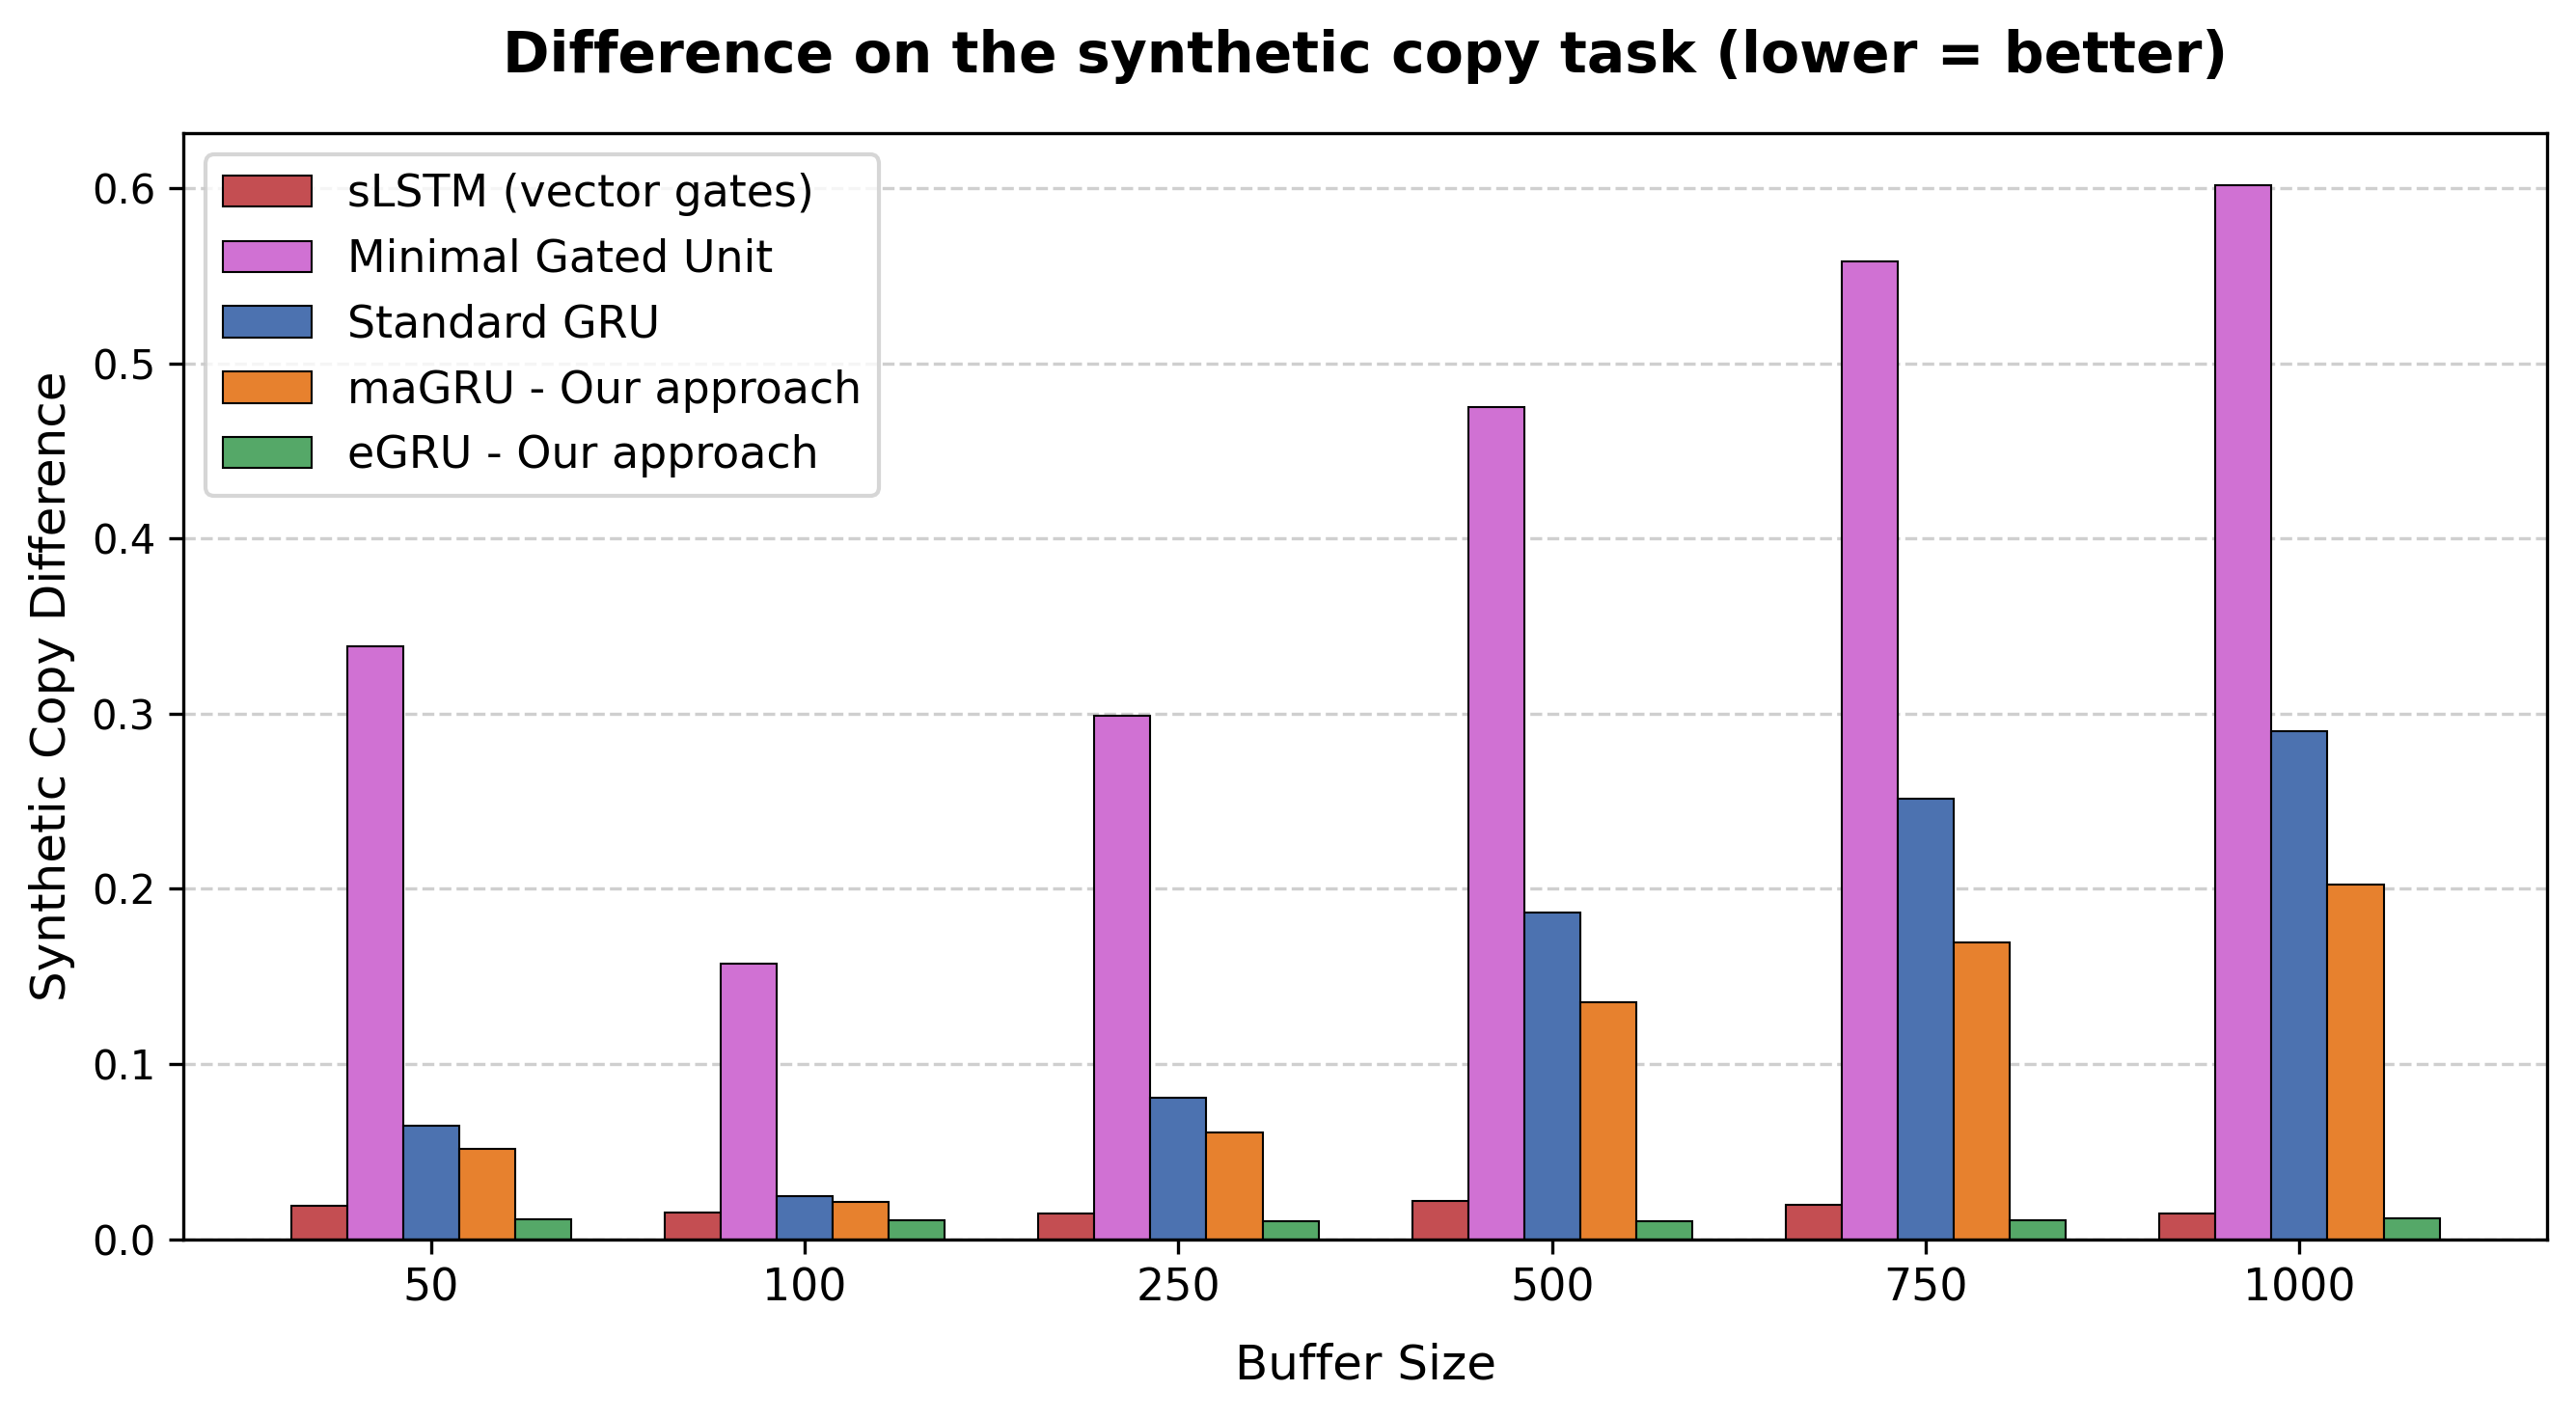

In [7]:
standard_gru = [
    0.06472772378290054,
    0.024783416346895813,
    0.08087871441304094,
    0.1865408441217819,
    0.25148515299995344,
    0.2897896096848025,
]

egru = [
    0.011324257626760714,
    0.011014851688471909,
    0.010024752696090848,
    0.010024752666122547,
    0.011014851667724623,
    0.01178836653534655,
]

magru = [
    0.051701733510535544,
    0.021101485479088262,
    0.06089109021912117,
    0.1352722790129114,
    0.1696163402630551,
    0.2024133693758804,
]

MGU = [
    0.33876856954971163,
    0.15736386460242885,
    0.29910272890978523,
    0.4750309465545239,
    0.5580445646059395,
    0.6017636261364021,
]

sLSTM = [
    0.018750000237063927,
    0.015340909488837828,
    0.01477272766218944,
    0.021875000579959968,
    0.019602273252199997,
    0.014488636431368914,
]


import matplotlib.pyplot as plt
import numpy as np

# Data

buffer_sizes = ["50", "100", "250", "500", "750", "1000"]



# Plot setup

x = np.arange(len(buffer_sizes))
width = 0.15

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)


# Create bars

rects0 = ax.bar(
    x - 2 * width,
    sLSTM,
    width,
    label="sLSTM (vector gates)",
    color="#C44E52",
    edgecolor="black",
    linewidth=0.5,
)

rects1 = ax.bar(
    x - width,
    MGU,
    width,
    label="Minimal Gated Unit",
    color="#D071D3",
    edgecolor="black",
    linewidth=0.5,
)

rects2 = ax.bar(
    x,
    standard_gru,
    width,
    label="Standard GRU",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

rects3 = ax.bar(
    x + width,
    magru,
    width,
    label="maGRU - Our approach",
    color="#E7812E",
    edgecolor="black",
    linewidth=0.5,
)

rects4 = ax.bar(
    x + 2 * width,
    egru,
    width,
    label="eGRU - Our approach",
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)


# Titles and labels

ax.set_title(
    "Difference on the synthetic copy task (lower = better)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel(
    "Buffer Size",
    fontsize=12,
    fontweight="medium",
    labelpad=8,
)

ax.set_ylabel(
    "Synthetic Copy Difference",
    fontsize=12,
    fontweight="medium",
)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=11)


# Aesthetics

ax.legend(fontsize=11, frameon=True)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.6,
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()